<a href="https://colab.research.google.com/github/Zafar488/Portfolio/blob/main/FetalWatch_FINAL_V2_Industry_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MaaHifazat AI — FetalWatch FINAL V2

## Corrected Industry-Level Five-Public-Dataset Google Colab Workflow

This notebook develops the clinic/hospital **FetalWatch** system.

### Primary deployed output

The main model classifies 21 precomputed cardiotocography features into:

- `Normal`
- `Suspicious`
- `Pathological`

### Five automatically downloaded real-world sources

1. **UCI Cardiotocography** — primary expert `NSP` three-class labels.
2. **CTU-UHB** — intrapartum FHR/uterine-contraction recordings and delivery outcomes.
3. **FHRMA** — expert fetal-heart-rate morphology annotations.
4. **NIFEA** — fetal ECG arrhythmia and normal-rhythm recordings.
5. **ADFECGDB** — abdominal and direct fetal ECG reference recordings.

Only UCI contains the exact deployed `Normal / Suspicious / Pathological`
target. The other sources are integrated as separate research evidence,
validation datasets, and auxiliary heads. The notebook **never fabricates
NSP labels** for incompatible sources.

### Corrections in FINAL V2

- FHRMA signal/annotation files are matched by numeric record ID.
- Morphology annotation coverage and agreement are explicitly audited.
- Weak auxiliary heads are automatically disabled by validation gates.
- Arbitrary manual evidence flags are no longer trusted by the API.
- The API validates physiological ranges and feature consistency.
- Out-of-distribution warnings use training quantiles.
- Pathological thresholding uses calibrated out-of-fold probabilities.
- False negatives, confidence intervals, drift reference statistics, and
  feature importance are exported.
- A deterministic LangGraph-ready evidence-fusion tool is included.
- No duplicate CTU processing or notebook-only `run_cell_id` command exists.

> **Clinical notice:** This is a research and hackathon prototype. A
> qualified obstetric clinician must review all suspicious or pathological
> results. It is not a certified medical device.

## 1. Install dependencies

In [1]:
%%capture
!pip install -U \
  "pandas>=2.2,<4.0" "numpy>=1.26,<3.0" "scipy>=1.13" \
  "matplotlib>=3.8" "scikit-learn==1.9.0" \
  "xgboost>=3.0,<4.0" "lightgbm>=4.5,<5.0" \
  "ucimlrepo>=0.0.7" "wfdb>=4.2" "pyedflib>=0.1.40" \
  "requests>=2.32" "joblib>=1.4" "pyarrow>=16.0" \
  "fastapi>=0.115" "uvicorn>=0.34" "pydantic>=2.10"

## 2. Imports and configuration

In [35]:
from __future__ import annotations

import hashlib
import inspect
import json
import random
import re
import shutil
import sys
import tarfile
import warnings
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Mapping

import joblib
import lightgbm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyedflib
import requests
import sklearn
import wfdb
import xgboost

from lightgbm import LGBMClassifier
from scipy.signal import butter, filtfilt, find_peaks, periodogram
from scipy.stats import entropy, kurtosis, randint, loguniform, skew, spearmanr, uniform
from scipy import integrate
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    ParameterSampler,
    StratifiedGroupKFold,
    StratifiedKFold,
)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.utils.validation import has_fit_parameter
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

SEED = 42
FAST_MODE = True
CV_SPLITS = 5
TUNING_ITERATIONS = 12 if FAST_MODE else 40
BOOTSTRAP_ITERATIONS = 400 if FAST_MODE else 2000
TARGET_PATHOLOGICAL_RECALL = 0.92
MODEL_VERSION = "2.0.0"
MAX_HIGH_RATE_SECONDS = 300

# Research-only CTU outcome definition. This is not a clinical treatment rule.
CTU_ACIDEMIA_PH_THRESHOLD = 7.15

np.random.seed(SEED)
random.seed(SEED)

ROOT = Path("/content/fetalwatch_final_v2")
RAW_DIR = ROOT / "raw"
EXTRACTED_DIR = ROOT / "extracted"
PROCESSED_DIR = ROOT / "processed"
ARTIFACT_DIR = ROOT / "artifacts"

for directory in [RAW_DIR, EXTRACTED_DIR, PROCESSED_DIR, ARTIFACT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("XGBoost:", xgboost.__version__)
print("LightGBM:", lightgbm.__version__)
print("Project root:", ROOT)

Python: 3.12.13
pandas: 3.0.3
scikit-learn: 1.9.0
XGBoost: 3.3.0
LightGBM: 4.7.0
Project root: /content/fetalwatch_final_v2


## 3. Source registry

In [2]:
SOURCE_REGISTRY = {
    "uci_cardio": {
        "role": "primary_supervised_three_class",
        "repository_id": 193,
    },
    "ctu_uhb": {
        "role": "auxiliary_acidemia_and_external_ctg_validation",
        "zenodo_record": "19510407",
    },
    "fhrma": {
        "role": "expert_morphology_validation",
        "zenodo_record": "19510407",
    },
    "nifea": {
        "role": "auxiliary_arrhythmia_evidence",
        "physionet_path": "nifeadb/1.0.0",
    },
    "adfecgdb": {
        "role": "direct_reference_signal_quality_validation",
        "physionet_path": "adfecgdb/1.0.0",
    },
}
display(pd.DataFrame(SOURCE_REGISTRY).T)

,role,repository_id,zenodo_record,physionet_path
uci_cardio,primary_supervised_three_class,193,NaN,NaN
ctu_uhb,auxiliary_acidemia_and_external_ctg_validation,NaN,19510407,NaN
fhrma,expert_morphology_validation,NaN,19510407,NaN
nifea,auxiliary_arrhythmia_evidence,NaN,NaN,nifeadb/1.0.0
adfecgdb,direct_reference_signal_quality_validation,NaN,NaN,adfecgdb/1.0.0


## 4. Download helpers

In [3]:
def stream_download(url: str, output_path: Path, expected_md5: str | None = None) -> Path:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    if output_path.exists() and output_path.stat().st_size > 0:
        print("Already downloaded:", output_path.name)
        return output_path

    with requests.get(url, stream=True, timeout=300) as response:
        response.raise_for_status()
        with output_path.open("wb") as file:
            for chunk in response.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    file.write(chunk)

    if expected_md5:
        digest = hashlib.md5(output_path.read_bytes()).hexdigest()
        if digest.lower() != expected_md5.lower():
            output_path.unlink(missing_ok=True)
            raise ValueError(f"Checksum mismatch: {output_path.name}")
    return output_path


def download_zenodo_file(record_id: str, filename: str) -> Path:
    response = requests.get(
        f"https://zenodo.org/api/records/{record_id}", timeout=90
    )
    response.raise_for_status()
    metadata = response.json()

    item = next(
        (x for x in metadata.get("files", []) if x.get("key") == filename),
        None,
    )
    if item is None:
        available = [x.get("key") for x in metadata.get("files", [])]
        raise FileNotFoundError(f"{filename} not found. Available: {available}")

    url = item.get("links", {}).get("content") or item.get("links", {}).get("self")
    checksum = item.get("checksum", "")
    md5 = checksum.split(":", 1)[1] if checksum.startswith("md5:") else None
    return stream_download(url, RAW_DIR / filename, md5)


def safe_extract_tar(archive_path: Path, destination: Path) -> Path:
    destination.mkdir(parents=True, exist_ok=True)
    if any(destination.iterdir()):
        return destination

    with tarfile.open(archive_path, "r:*") as archive:
        destination_root = destination.resolve()
        for member in archive.getmembers():
            target = (destination / member.name).resolve()
            if not str(target).startswith(str(destination_root)):
                raise ValueError(f"Unsafe archive path: {member.name}")
        archive.extractall(destination)
    return destination


def download_text(url: str) -> str:
    response = requests.get(url, timeout=90)
    response.raise_for_status()
    return response.text

## 5. Automatically download CTU-UHB and FHRMA

In [4]:
CTGDL_RECORD_ID = "19510407"
CTGDL_FILES = {
    "ctu_processed": "CTGDL_ctu_uhb_proc_csv.tar.gz",
    "ctu_metadata": "ctu_uhb_metadata.csv",
    "fhrma_processed": "CTGDL_FHRMA_proc_csv.tar.gz",
    "fhrma_annotations": "CTGDL_FHRMA_ano_csv.tar.gz",
    "fhrma_metadata": "CTGDL_FHEMA_metadata.csv",
}

ctgdl_paths = {
    key: download_zenodo_file(CTGDL_RECORD_ID, filename)
    for key, filename in CTGDL_FILES.items()
}

ctu_signal_root = safe_extract_tar(
    ctgdl_paths["ctu_processed"], EXTRACTED_DIR / "ctu_uhb"
)
fhrma_signal_root = safe_extract_tar(
    ctgdl_paths["fhrma_processed"], EXTRACTED_DIR / "fhrma_signals"
)
fhrma_annotation_root = safe_extract_tar(
    ctgdl_paths["fhrma_annotations"], EXTRACTED_DIR / "fhrma_annotations"
)

ctu_metadata_raw = pd.read_csv(ctgdl_paths["ctu_metadata"], low_memory=False)
fhrma_metadata_raw = pd.read_csv(ctgdl_paths["fhrma_metadata"], low_memory=False)

print("CTU metadata:", ctu_metadata_raw.shape)
print("FHRMA metadata:", fhrma_metadata_raw.shape)

CTU metadata: (552, 42)
FHRMA metadata: (135, 16)


## 6. Load UCI Cardiotocography

In [5]:
from ucimlrepo import fetch_ucirepo

UCI_RAW_FEATURES = [
    "LB", "AC", "FM", "UC", "DL", "DS", "DP",
    "ASTV", "MSTV", "ALTV", "MLTV",
    "Width", "Min", "Max", "Nmax", "Nzeros",
    "Mode", "Mean", "Median", "Variance", "Tendency",
]

ID_TO_LABEL = {0: "normal", 1: "suspicious", 2: "pathological"}
PATHOLOGICAL_ID = 2


def load_uci_cardio() -> tuple[pd.DataFrame, pd.Series]:
    dataset = fetch_ucirepo(id=193)
    features = dataset.data.features.copy()
    targets = dataset.data.targets.copy()
    features.columns = [str(c).strip() for c in features.columns]

    if isinstance(targets, pd.Series):
        target_series = targets
    elif "NSP" in targets.columns:
        target_series = targets["NSP"]
    elif "NSP" in features.columns:
        target_series = features.pop("NSP")
    else:
        matching = [c for c in targets.columns if str(c).strip().upper() == "NSP"]
        if not matching:
            raise ValueError(f"NSP target not found: {targets.columns.tolist()}")
        target_series = targets[matching[0]]

    missing = [f for f in UCI_RAW_FEATURES if f not in features.columns]
    if missing:
        raise ValueError(f"Missing UCI features: {missing}")

    X = features[UCI_RAW_FEATURES].apply(pd.to_numeric, errors="coerce")
    labels = target_series.astype(str).str.strip().str.lower()
    label_map = {
        "1": 0, "n": 0, "normal": 0,
        "2": 1, "s": 1, "suspect": 1, "suspicious": 1,
        "3": 2, "p": 2, "pathologic": 2, "pathological": 2,
    }
    y = labels.map(label_map)
    if y.isna().any():
        raise ValueError(f"Unmapped NSP labels: {labels[y.isna()].unique().tolist()}")
    return X.reset_index(drop=True), y.astype(int).reset_index(drop=True)


X_uci_raw, y_uci = load_uci_cardio()
print("UCI:", X_uci_raw.shape)
display(y_uci.map(ID_TO_LABEL).value_counts().to_frame("count"))

UCI: (2126, 21)


,count
NSP,
normal,1655
suspicious,295
pathological,176


## 7. Validate and group duplicate UCI records

In [6]:
UCI_SANITY_BOUNDS = {
    "LB": (50, 220), "AC": (0, 1), "FM": (0, 1), "UC": (0, 1),
    "DL": (0, 1), "DS": (0, 1), "DP": (0, 1),
    "ASTV": (0, 100), "MSTV": (0, 20),
    "ALTV": (0, 100), "MLTV": (0, 100),
    "Width": (0, 250), "Min": (30, 240), "Max": (50, 260),
    "Nmax": (0, 50), "Nzeros": (0, 50),
    "Mode": (30, 240), "Mean": (30, 240), "Median": (30, 240),
    "Variance": (0, 500), "Tendency": (-1, 1),
}

for feature, (lower, upper) in UCI_SANITY_BOUNDS.items():
    invalid = X_uci_raw[feature].notna() & ~X_uci_raw[feature].between(lower, upper)
    X_uci_raw.loc[invalid, feature] = np.nan

signatures = pd.util.hash_pandas_object(
    X_uci_raw.round(10).astype(str), index=False
).astype(str)

label_counts = (
    pd.DataFrame({"signature": signatures, "target": y_uci})
    .groupby("signature")["target"]
    .nunique()
)
ambiguous = set(label_counts[label_counts > 1].index)

keep = ~signatures.isin(ambiguous)
X_uci = X_uci_raw.loc[keep].reset_index(drop=True)
y_uci_clean = y_uci.loc[keep].reset_index(drop=True)
groups_uci = signatures.loc[keep].reset_index(drop=True)

print("Rows after ambiguous-signature removal:", len(X_uci))
print("Unique signatures:", groups_uci.nunique())

Rows after ambiguous-signature removal: 2122
Unique signatures: 2109


## 8. Portable feature engineering

In [7]:
%%writefile fetalwatch_tabular_features.py
from __future__ import annotations
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

RAW_FEATURES = (
    "LB","AC","FM","UC","DL","DS","DP","ASTV","MSTV","ALTV","MLTV",
    "Width","Min","Max","Nmax","Nzeros","Mode","Mean","Median",
    "Variance","Tendency",
)

class FetalWatchFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, raw_features=RAW_FEATURES):
        self.raw_features = raw_features

    def fit(self, X, y=None):
        self.feature_names_in_ = np.asarray(list(self.raw_features), dtype=object)
        return self

    def transform(self, X):
        columns = list(self.raw_features)
        frame = (
            X.reindex(columns=columns).copy()
            if isinstance(X, pd.DataFrame)
            else pd.DataFrame(X, columns=columns)
        )
        frame = frame.apply(pd.to_numeric, errors="coerce")
        eps = 1e-8

        frame["TotalDecelerationRate"] = frame["DL"] + frame["DS"] + frame["DP"]
        frame["SevereDecelerationBurden"] = frame["DS"] + 2 * frame["DP"]
        frame["AccelerationDecelerationBalance"] = (
            frame["AC"] - frame["TotalDecelerationRate"]
        )
        frame["ActivityRate"] = frame["FM"] + frame["UC"]
        frame["AccelerationToContractionRatio"] = frame["AC"] / (frame["UC"].abs() + eps)
        frame["DecelerationToContractionRatio"] = (
            frame["TotalDecelerationRate"] / (frame["UC"].abs() + eps)
        )
        frame["VariabilityComposite"] = frame["MSTV"] + frame["MLTV"]
        frame["AbnormalVariabilityBurden"] = frame["ASTV"] + frame["ALTV"]
        frame["HistogramRangeCheck"] = frame["Max"] - frame["Min"]
        frame["CenterSpread"] = (
            (frame["Mean"] - frame["Median"]).abs()
            + (frame["Median"] - frame["Mode"]).abs()
        )
        frame["BaselineMeanDifference"] = frame["LB"] - frame["Mean"]
        frame["BaselineMedianDifference"] = frame["LB"] - frame["Median"]
        frame["VarianceLog1p"] = np.log1p(frame["Variance"].clip(lower=0))
        frame["PeakDensityProxy"] = frame["Nmax"] / (frame["Width"].abs() + eps)
        frame["ZeroPeakRatio"] = frame["Nzeros"] / (frame["Nmax"].abs() + 1)
        frame["ASTV_MSTV_Interaction"] = frame["ASTV"] * frame["MSTV"]
        frame["ALTV_MLTV_Interaction"] = frame["ALTV"] * frame["MLTV"]
        frame["DecelerationVarianceInteraction"] = (
            frame["TotalDecelerationRate"] * frame["VarianceLog1p"]
        )
        return frame

Writing fetalwatch_tabular_features.py


In [8]:
from sklearn.base import clone
from fetalwatch_tabular_features import FetalWatchFeatureEngineer

engineer = FetalWatchFeatureEngineer()
clone(engineer)
preview = engineer.fit_transform(X_uci.head())
assert preview.shape[1] > len(UCI_RAW_FEATURES)
print("Feature engineering smoke test passed:", preview.shape)

Feature engineering smoke test passed: (5, 39)


## 9. Duplicate- and class-balanced weights

In [9]:
def calculate_uci_weights(targets: pd.Series, groups: pd.Series) -> np.ndarray:
    table = pd.DataFrame({
        "target": targets.reset_index(drop=True),
        "group": groups.reset_index(drop=True),
    })
    duplicate_weight = 1.0 / table.groupby("group")["group"].transform("size").astype(float)
    effective = (
        pd.DataFrame({"target": table["target"], "w": duplicate_weight})
        .groupby("target")["w"]
        .sum()
    )
    weights = np.array([
        duplicate_weight.iloc[i] / float(effective.loc[target])
        for i, target in enumerate(table["target"])
    ])
    return weights / weights.mean()

## 10. Group-safe held-out split

In [10]:
outer = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
train_idx, test_idx = next(outer.split(X_uci, y_uci_clean, groups=groups_uci))

X_train = X_uci.iloc[train_idx].reset_index(drop=True)
X_test = X_uci.iloc[test_idx].reset_index(drop=True)
y_train = y_uci_clean.iloc[train_idx].reset_index(drop=True)
y_test = y_uci_clean.iloc[test_idx].reset_index(drop=True)
groups_train = groups_uci.iloc[train_idx].reset_index(drop=True)
groups_test = groups_uci.iloc[test_idx].reset_index(drop=True)

assert set(groups_train).isdisjoint(set(groups_test))
display(pd.DataFrame({
    "train": y_train.value_counts().sort_index(),
    "test": y_test.value_counts().sort_index(),
}).rename(index=ID_TO_LABEL))

,train,test
NSP,,
normal,1323,330
suspicious,234,59
pathological,140,36


## 11. Candidate models

In [11]:
tree_preprocessor = Pipeline([
    ("features", FetalWatchFeatureEngineer()),
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
])
neural_preprocessor = Pipeline([
    ("features", FetalWatchFeatureEngineer()),
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", RobustScaler()),
])

CANDIDATE_MODELS = {
    "random_forest": Pipeline([
        ("preprocess", tree_preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=600, min_samples_leaf=2,
            random_state=SEED, n_jobs=1,
        )),
    ]),
    "xgboost": Pipeline([
        ("preprocess", tree_preprocessor),
        ("model", XGBClassifier(
            objective="multi:softprob", num_class=3, eval_metric="mlogloss",
            n_estimators=500, max_depth=4, learning_rate=0.04,
            min_child_weight=2, subsample=0.85, colsample_bytree=0.85,
            reg_alpha=0.01, reg_lambda=3.0, random_state=SEED,
            tree_method="hist", n_jobs=1,
        )),
    ]),
    "lightgbm": Pipeline([
        ("preprocess", tree_preprocessor),
        ("model", LGBMClassifier(
            objective="multiclass", num_class=3, n_estimators=500,
            learning_rate=0.04, num_leaves=31, random_state=SEED,
            n_jobs=1, verbosity=-1,
        )),
    ]),
    "multilayer_perceptron": Pipeline([
        ("preprocess", neural_preprocessor),
        ("model", MLPClassifier(
            hidden_layer_sizes=(128, 64), alpha=1e-3,
            learning_rate_init=1e-3, early_stopping=True,
            validation_fraction=0.15, max_iter=600, random_state=SEED,
        )),
    ]),
}

## 12. Safety-focused metrics

In [12]:
def pathological_recall(y_true, y_pred, sample_weight=None):
    return recall_score(
        y_true, y_pred, labels=[2], average="macro",
        sample_weight=sample_weight, zero_division=0,
    )

def pathological_precision(y_true, y_pred, sample_weight=None):
    return precision_score(
        y_true, y_pred, labels=[2], average="macro",
        sample_weight=sample_weight, zero_division=0,
    )

def safety_score(y_true, y_pred, sample_weight=None):
    recall = pathological_recall(y_true, y_pred, sample_weight)
    macro = f1_score(
        y_true, y_pred, average="macro",
        sample_weight=sample_weight, zero_division=0,
    )
    balanced = balanced_accuracy_score(y_true, y_pred, sample_weight=sample_weight)
    return 0.60 * recall + 0.30 * macro + 0.10 * balanced

def multiclass_metrics(y_true, pred, prob, sample_weight=None):
    return {
        "safety": safety_score(y_true, pred, sample_weight),
        "accuracy": accuracy_score(y_true, pred, sample_weight=sample_weight),
        "balanced_accuracy": balanced_accuracy_score(
            y_true, pred, sample_weight=sample_weight
        ),
        "macro_f1": f1_score(
            y_true, pred, average="macro",
            sample_weight=sample_weight, zero_division=0,
        ),
        "pathological_recall": pathological_recall(y_true, pred, sample_weight),
        "pathological_precision": pathological_precision(y_true, pred, sample_weight),
        "roc_auc_ovr_macro": roc_auc_score(
            y_true, prob, multi_class="ovr", average="macro",
            sample_weight=sample_weight, labels=[0, 1, 2],
        ),
        "log_loss": log_loss(
            y_true, prob, labels=[0, 1, 2], sample_weight=sample_weight
        ),
    }

## 13. Weighted cross-validation benchmark

In [13]:
inner = StratifiedGroupKFold(n_splits=CV_SPLITS, shuffle=True, random_state=SEED)
CV_SPLITS_LIST = list(inner.split(X_train, y_train, groups=groups_train))

def fit_weighted(estimator, X, y, groups):
    weights = calculate_uci_weights(y, groups)
    model = clone(estimator)
    final_estimator = model.named_steps["model"]

    if has_fit_parameter(final_estimator, "sample_weight"):
        model.fit(
            X,
            y,
            model__sample_weight=weights,
        )
    else:
        # Compatibility fallback for estimators without sample_weight.
        # Weighted bootstrap keeps the benchmark runnable and explicit.
        rng = np.random.default_rng(SEED)
        probabilities = weights / weights.sum()
        sampled_indices = rng.choice(
            np.arange(len(y)),
            size=len(y),
            replace=True,
            p=probabilities,
        )
        model.fit(
            X.iloc[sampled_indices],
            y.iloc[sampled_indices],
        )

    return model

def evaluate_cv(estimator):
    rows = []
    for fold, (fit_idx, val_idx) in enumerate(CV_SPLITS_LIST, 1):
        model = fit_weighted(
            estimator,
            X_train.iloc[fit_idx], y_train.iloc[fit_idx],
            groups_train.iloc[fit_idx],
        )
        prob = model.predict_proba(X_train.iloc[val_idx])
        pred = np.argmax(prob, axis=1)
        weights = calculate_uci_weights(
            y_train.iloc[val_idx], groups_train.iloc[val_idx]
        )
        metrics = multiclass_metrics(y_train.iloc[val_idx], pred, prob, weights)
        metrics["fold"] = fold
        rows.append(metrics)
    return pd.DataFrame(rows)

benchmark_rows = []
for name, estimator in CANDIDATE_MODELS.items():
    print("Evaluating:", name)
    report = evaluate_cv(estimator)
    report.to_csv(ARTIFACT_DIR / f"cv_{name}.csv", index=False)
    benchmark_rows.append({
        "model": name,
        **{f"mean_{c}": report[c].mean() for c in [
            "safety", "macro_f1", "balanced_accuracy",
            "pathological_recall", "pathological_precision",
            "roc_auc_ovr_macro",
        ]},
    })

benchmark = pd.DataFrame(benchmark_rows).sort_values(
    ["mean_safety", "mean_roc_auc_ovr_macro"], ascending=False
).reset_index(drop=True)
display(benchmark.round(4))
benchmark.to_csv(ARTIFACT_DIR / "primary_model_benchmark.csv", index=False)

Evaluating: random_forest
Evaluating: xgboost
Evaluating: lightgbm
Evaluating: multilayer_perceptron


,model,mean_safety,mean_macro_f1,mean_balanced_accuracy,mean_pathological_recall,mean_pathological_precision,mean_roc_auc_ovr_macro
0,xgboost,0.9227,0.9151,0.9154,0.9278,0.9697,0.9860
1,lightgbm,0.9098,0.9045,0.9051,0.9132,0.9714,0.9849
2,random_forest,0.9046,0.9020,0.9019,0.9063,0.9586,0.9832
3,multilayer_perceptron,0.8198,0.8195,0.8194,0.8201,0.8432,0.9084


## 14. Custom weighted hyperparameter tuning

In [14]:
best_family = benchmark.iloc[0]["model"]
base_estimator = CANDIDATE_MODELS[best_family]

PARAMETER_SPACES = {
    "random_forest": {
        "model__n_estimators": randint(350, 1000),
        "model__max_depth": [None, 5, 8, 12, 16, 24],
        "model__min_samples_split": randint(2, 18),
        "model__min_samples_leaf": randint(1, 8),
        "model__max_features": ["sqrt", "log2", 0.6, 0.8, None],
    },
    "xgboost": {
        "model__n_estimators": randint(250, 900),
        "model__max_depth": randint(2, 9),
        "model__learning_rate": loguniform(0.01, 0.20),
        "model__min_child_weight": randint(1, 10),
        "model__subsample": uniform(0.65, 0.35),
        "model__colsample_bytree": uniform(0.65, 0.35),
        "model__reg_alpha": loguniform(1e-5, 2.0),
        "model__reg_lambda": loguniform(0.1, 15.0),
        "model__gamma": uniform(0.0, 1.0),
    },
    "lightgbm": {
        "model__n_estimators": randint(250, 900),
        "model__learning_rate": loguniform(0.01, 0.20),
        "model__num_leaves": randint(15, 96),
        "model__max_depth": [-1, 4, 6, 8, 12, 16],
        "model__min_child_samples": randint(10, 80),
        "model__subsample": uniform(0.65, 0.35),
        "model__colsample_bytree": uniform(0.65, 0.35),
        "model__reg_alpha": loguniform(1e-5, 2.0),
        "model__reg_lambda": loguniform(0.1, 15.0),
    },
    "multilayer_perceptron": {
        "model__hidden_layer_sizes": [
            (64,), (96,), (128,), (96, 48),
            (128, 64), (128, 64, 32),
        ],
        "model__alpha": loguniform(1e-5, 1e-1),
        "model__learning_rate_init": loguniform(1e-4, 5e-3),
        "model__activation": ["relu", "tanh"],
    },
}

parameter_candidates = list(ParameterSampler(
    PARAMETER_SPACES[best_family],
    n_iter=TUNING_ITERATIONS,
    random_state=SEED,
))

tuning_rows = []

for number, parameters in enumerate(parameter_candidates, 1):
    print(f"Candidate {number}/{len(parameter_candidates)}")
    estimator = clone(base_estimator).set_params(**parameters)
    report = evaluate_cv(estimator)
    tuning_rows.append({
        "candidate": number,
        "parameters": parameters,
        **{f"mean_{c}": report[c].mean() for c in [
            "safety", "macro_f1", "balanced_accuracy",
            "pathological_recall", "pathological_precision",
            "roc_auc_ovr_macro",
        ]},
        "std_safety": report["safety"].std(),
    })

tuning_results = pd.DataFrame(tuning_rows).sort_values(
    ["mean_safety", "mean_roc_auc_ovr_macro", "std_safety"],
    ascending=[False, False, True],
).reset_index(drop=True)

best_parameters = tuning_results.iloc[0]["parameters"]
best_estimator = clone(base_estimator).set_params(**best_parameters)

print("Selected family:", best_family)
print(json.dumps(best_parameters, indent=2, default=str))
display(tuning_results.head(10))

tuning_export = tuning_results.copy()
tuning_export["parameters"] = tuning_export["parameters"].map(
    lambda value: json.dumps(value, default=str)
)
tuning_export.to_csv(
    ARTIFACT_DIR / "primary_weighted_tuning.csv",
    index=False,
)

Candidate 1/12
Candidate 2/12
Candidate 3/12
Candidate 4/12
Candidate 5/12
Candidate 6/12
Candidate 7/12
Candidate 8/12
Candidate 9/12
Candidate 10/12
Candidate 11/12
Candidate 12/12
Selected family: xgboost
{
  "model__colsample_bytree": 0.7465997137078901,
  "model__gamma": 0.2962735057040824,
  "model__learning_rate": 0.016406549192101497,
  "model__max_depth": 2,
  "model__min_child_weight": 7,
  "model__n_estimators": 770,
  "model__reg_alpha": 0.12407740046553102,
  "model__reg_lambda": 0.27065961369409125,
  "model__subsample": 0.6519327409932608
}


,candidate,parameters,mean_safety,mean_macro_f1,mean_balanced_accuracy,mean_pathological_recall,mean_pathological_precision,mean_roc_auc_ovr_macro,std_safety
0,9,{'model__colsample_bytree': 0.7465997137078901...,0.933371,0.919979,0.919805,0.942328,0.963506,0.983016,0.018408
1,8,{'model__colsample_bytree': 0.6809723757181718...,0.931757,0.915944,0.915774,0.942328,0.966407,0.983937,0.018692
2,11,{'model__colsample_bytree': 0.8681543443896453...,0.931491,0.926326,0.926413,0.934921,0.971898,0.985024,0.026093
3,6,{'model__colsample_bytree': 0.6927133821956726...,0.930801,0.924183,0.924347,0.935185,0.969927,0.986932,0.012445
4,12,{'model__colsample_bytree': 0.7840244061638264...,0.930723,0.924037,0.924005,0.935185,0.967633,0.985480,0.012344
5,1,{'model__colsample_bytree': 0.7810890415965769...,0.929925,0.921994,0.922157,0.935185,0.964965,0.985893,0.010639
6,5,{'model__colsample_bytree': 0.8881076385057229...,0.927771,0.905978,0.905808,0.942328,0.963944,0.978784,0.017514
7,7,{'model__colsample_bytree': 0.8413485977701479...,0.926199,0.923804,0.923913,0.927778,0.963741,0.984083,0.021574
8,4,{'model__colsample_bytree': 0.9908144315945107...,0.924420,0.919396,0.919346,0.927778,0.972827,0.985550,0.019647
9,10,"{'model__colsample_bytree': 0.935411499959192,...",0.919956,0.918949,0.918905,0.920635,0.965085,0.983042,0.022808


## 15. Out-of-fold probabilities and multiclass calibration

In [15]:
def generate_oof_probabilities(estimator):
    probabilities = np.full((len(X_train), 3), np.nan)
    for fit_idx, val_idx in CV_SPLITS_LIST:
        model = fit_weighted(
            estimator,
            X_train.iloc[fit_idx], y_train.iloc[fit_idx],
            groups_train.iloc[fit_idx],
        )
        probabilities[val_idx] = model.predict_proba(X_train.iloc[val_idx])
    if np.isnan(probabilities).any():
        raise RuntimeError("Incomplete OOF probabilities.")
    return probabilities

def probability_to_logit(probabilities):
    clipped = np.clip(np.asarray(probabilities, dtype=float), 1e-6, 1 - 1e-6)
    return np.log(clipped / (1 - clipped)).reshape(-1, 1)

def fit_multiclass_calibrators(raw_probabilities, targets, weights):
    calibrators = []
    for class_id in [0, 1, 2]:
        binary = (targets.to_numpy() == class_id).astype(int)
        calibrator = LogisticRegression(
            C=1e6, solver="lbfgs", max_iter=3000, random_state=SEED
        )
        calibrator.fit(
            probability_to_logit(raw_probabilities[:, class_id]),
            binary,
            sample_weight=weights,
        )
        calibrators.append(calibrator)
    return calibrators

def apply_multiclass_calibrators(calibrators, raw_probabilities):
    columns = []
    for class_id, calibrator in enumerate(calibrators):
        columns.append(
            calibrator.predict_proba(
                probability_to_logit(raw_probabilities[:, class_id])
            )[:, 1]
        )
    calibrated = np.column_stack(columns)
    return calibrated / np.clip(calibrated.sum(axis=1, keepdims=True), 1e-12, None)

oof_raw_probabilities = generate_oof_probabilities(best_estimator)
oof_weights = calculate_uci_weights(y_train, groups_train)
class_calibrators = fit_multiclass_calibrators(
    oof_raw_probabilities, y_train, oof_weights
)
oof_calibrated_probabilities = apply_multiclass_calibrators(
    class_calibrators, oof_raw_probabilities
)

assert np.allclose(oof_calibrated_probabilities.sum(axis=1), 1.0)
print("OOF calibration complete.")

OOF calibration complete.


## 16. Optimize pathological threshold

In [16]:
def apply_pathological_threshold(probabilities, threshold):
    predictions = np.argmax(probabilities, axis=1).astype(int)
    predictions[probabilities[:, 2] >= threshold] = 2
    return predictions

threshold_rows = []

for threshold in np.round(np.arange(0.05, 0.96, 0.01), 2):
    pred = apply_pathological_threshold(oof_calibrated_probabilities, threshold)
    metrics = multiclass_metrics(
        y_train, pred, oof_calibrated_probabilities, oof_weights
    )
    threshold_rows.append({"threshold": float(threshold), **metrics})

threshold_table = pd.DataFrame(threshold_rows)
eligible = threshold_table[
    threshold_table["pathological_recall"] >= TARGET_PATHOLOGICAL_RECALL
]

if not eligible.empty:
    selected = eligible.sort_values(
        ["macro_f1", "pathological_precision", "balanced_accuracy", "threshold"],
        ascending=[False, False, False, False],
    ).iloc[0]
else:
    selected = threshold_table.sort_values(
        ["pathological_recall", "macro_f1", "pathological_precision"],
        ascending=False,
    ).iloc[0]

PATHOLOGICAL_THRESHOLD = float(selected["threshold"])
print("Selected pathological threshold:", PATHOLOGICAL_THRESHOLD)
display(selected.to_frame("value"))
threshold_table.to_csv(
    ARTIFACT_DIR / "pathological_threshold_analysis.csv",
    index=False,
)

Selected pathological threshold: 0.95


,value
threshold,0.950000
safety,0.932927
accuracy,0.918520
balanced_accuracy,0.918520
macro_f1,0.918691
pathological_recall,0.942446
pathological_precision,0.959636
roc_auc_ovr_macro,0.982872
log_loss,0.234441


## 17. Held-out primary-model evaluation

In [17]:
primary_model = fit_weighted(best_estimator, X_train, y_train, groups_train)

raw_test_probabilities = primary_model.predict_proba(X_test)
calibrated_test_probabilities = apply_multiclass_calibrators(
    class_calibrators, raw_test_probabilities
)
test_predictions = apply_pathological_threshold(
    calibrated_test_probabilities, PATHOLOGICAL_THRESHOLD
)

test_weights = calculate_uci_weights(y_test, groups_test)

unweighted_test_metrics = multiclass_metrics(
    y_test, test_predictions, calibrated_test_probabilities
)
weighted_test_metrics = multiclass_metrics(
    y_test, test_predictions, calibrated_test_probabilities, test_weights
)

print("Unweighted:")
print(json.dumps(unweighted_test_metrics, indent=2))
print("\nDuplicate/class-balanced:")
print(json.dumps(weighted_test_metrics, indent=2))
print("\nClassification report:")
print(classification_report(
    y_test, test_predictions,
    target_names=["normal", "suspicious", "pathological"],
    zero_division=0,
))

Unweighted:
{
  "safety": 0.9681858828265901,
  "accuracy": 0.9294117647058824,
  "balanced_accuracy": 0.9650573531929464,
  "macro_f1": 0.9056004916909853,
  "pathological_recall": 1.0,
  "pathological_precision": 0.9,
  "roc_auc_ovr_macro": 0.9927037891974498,
  "log_loss": 0.2040141789181665
}

Duplicate/class-balanced:
{
  "safety": 0.9858575994338452,
  "accuracy": 0.9647886107223691,
  "balanced_accuracy": 0.9647886107223692,
  "macro_f1": 0.9645957945386944,
  "pathological_recall": 1.0,
  "pathological_precision": 0.9879154078549848,
  "roc_auc_ovr_macro": 0.9950190627573616,
  "log_loss": 0.12646282386387617
}

Classification report:
              precision    recall  f1-score   support

      normal       1.00      0.91      0.95       330
  suspicious       0.70      0.98      0.82        59
pathological       0.90      1.00      0.95        36

    accuracy                           0.93       425
   macro avg       0.87      0.97      0.91       425
weighted avg       0.95

<Figure size 700x600 with 0 Axes>

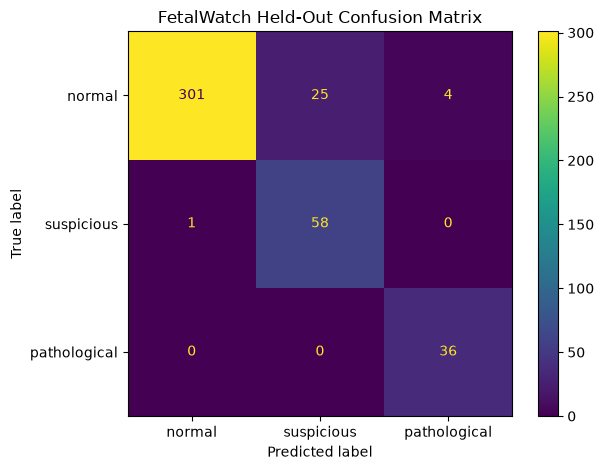

In [18]:
plt.figure(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    labels=[0, 1, 2],
    display_labels=["normal", "suspicious", "pathological"],
    values_format="d",
)
plt.title("FetalWatch Held-Out Confusion Matrix")
plt.tight_layout()
plt.show()

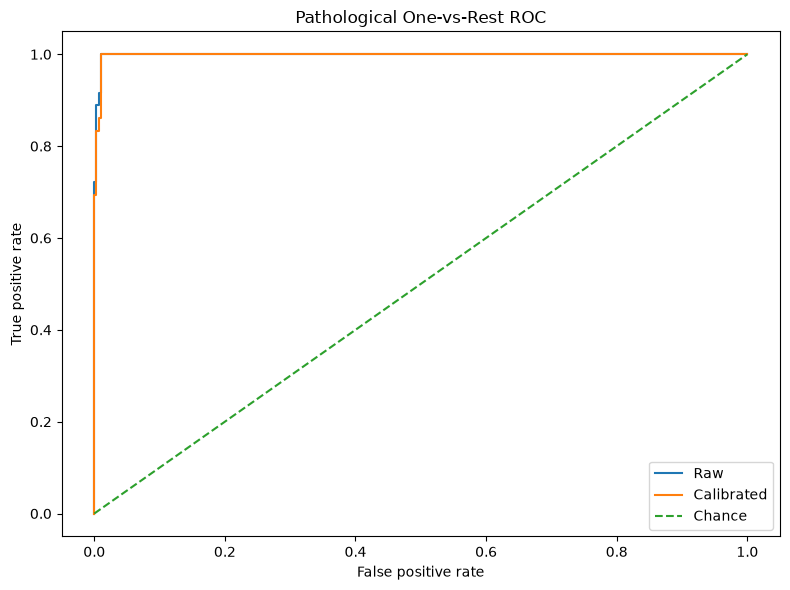

In [19]:
pathological_binary = (y_test.to_numpy() == 2).astype(int)

plt.figure(figsize=(8, 6))
for name, probabilities in {
    "Raw": raw_test_probabilities[:, 2],
    "Calibrated": calibrated_test_probabilities[:, 2],
}.items():
    fpr, tpr, _ = roc_curve(pathological_binary, probabilities)
    plt.plot(fpr, tpr, label=name)

plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")
plt.title("Pathological One-vs-Rest ROC")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend()
plt.tight_layout()
plt.show()

## 17B. False-negative audit, bootstrap confidence intervals, and feature importance

In [20]:
heldout_predictions = X_test.copy()
heldout_predictions["true_target"] = y_test
heldout_predictions["predicted_target"] = test_predictions
heldout_predictions["true_label"] = y_test.map(ID_TO_LABEL)
heldout_predictions["predicted_label"] = pd.Series(
    test_predictions
).map(ID_TO_LABEL)
heldout_predictions["normal_probability"] = (
    calibrated_test_probabilities[:, 0]
)
heldout_predictions["suspicious_probability"] = (
    calibrated_test_probabilities[:, 1]
)
heldout_predictions["pathological_probability"] = (
    calibrated_test_probabilities[:, 2]
)
heldout_predictions["pathological_false_negative"] = (
    (y_test.to_numpy() == PATHOLOGICAL_ID)
    & (test_predictions != PATHOLOGICAL_ID)
)

pathological_false_negatives = heldout_predictions[
    heldout_predictions["pathological_false_negative"]
].copy()

print(
    "Pathological false negatives:",
    len(pathological_false_negatives),
)
display(pathological_false_negatives.head(30))

heldout_predictions.to_csv(
    ARTIFACT_DIR / "heldout_predictions.csv",
    index=False,
)
pathological_false_negatives.to_csv(
    ARTIFACT_DIR / "pathological_false_negatives.csv",
    index=False,
)


def bootstrap_metric_intervals(
    y_true: np.ndarray,
    predictions: np.ndarray,
    probabilities: np.ndarray,
    iterations: int,
) -> dict:
    rng = np.random.default_rng(SEED)
    rows = []

    for _ in range(iterations):
        indices = rng.integers(
            0,
            len(y_true),
            size=len(y_true),
        )

        sampled_y = y_true[indices]
        if len(np.unique(sampled_y)) < 3:
            continue

        sampled_predictions = predictions[indices]
        sampled_probabilities = probabilities[indices]

        metrics = multiclass_metrics(
            sampled_y,
            sampled_predictions,
            sampled_probabilities,
        )
        rows.append(metrics)

    frame = pd.DataFrame(rows)
    intervals = {}

    for metric in [
        "macro_f1",
        "balanced_accuracy",
        "pathological_recall",
        "pathological_precision",
        "roc_auc_ovr_macro",
    ]:
        intervals[metric] = {
            "estimate": float(unweighted_test_metrics[metric]),
            "lower_95": float(frame[metric].quantile(0.025)),
            "upper_95": float(frame[metric].quantile(0.975)),
        }

    return intervals


primary_bootstrap_intervals = bootstrap_metric_intervals(
    y_test.to_numpy(),
    test_predictions,
    calibrated_test_probabilities,
    BOOTSTRAP_ITERATIONS,
)

print(json.dumps(primary_bootstrap_intervals, indent=2))

with open(
    ARTIFACT_DIR / "primary_bootstrap_intervals.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        primary_bootstrap_intervals,
        file,
        indent=2,
    )


importance = permutation_importance(
    primary_model,
    X_test,
    y_test,
    scoring="f1_macro",
    n_repeats=20 if FAST_MODE else 50,
    random_state=SEED,
    n_jobs=-1,
)

feature_importance = (
    pd.DataFrame({
        "feature": UCI_RAW_FEATURES,
        "importance_mean": importance.importances_mean,
        "importance_std": importance.importances_std,
    })
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance)
feature_importance.to_csv(
    ARTIFACT_DIR / "permutation_feature_importance.csv",
    index=False,
)

Pathological false negatives: 0


,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,...,Variance,Tendency,true_target,predicted_target,true_label,predicted_label,normal_probability,suspicious_probability,pathological_probability,pathological_false_negative


{
  "macro_f1": {
    "estimate": 0.9056004916909853,
    "lower_95": 0.8682823258707701,
    "upper_95": 0.9375295191129877
  },
  "balanced_accuracy": {
    "estimate": 0.9650573531929464,
    "lower_95": 0.9488635583836305,
    "upper_95": 0.9785583990557433
  },
  "pathological_recall": {
    "estimate": 1.0,
    "lower_95": 1.0,
    "upper_95": 1.0
  },
  "pathological_precision": {
    "estimate": 0.9,
    "lower_95": 0.7998717948717949,
    "upper_95": 0.9777777777777777
  },
  "roc_auc_ovr_macro": {
    "estimate": 0.9927037891974498,
    "lower_95": 0.9879974569381275,
    "upper_95": 0.9963820562418562
  }
}


,feature,importance_mean,importance_std
0,AC,0.082735,0.015553
1,LB,0.073336,0.007922
2,ASTV,0.068800,0.007736
3,Mean,0.061162,0.012417
4,ALTV,0.052683,0.013302
5,Median,0.047188,0.012621
6,Nmax,0.013385,0.004652
7,DP,0.012900,0.007289
8,MSTV,0.010408,0.004876
9,UC,0.009765,0.005165


## 18. Primary acceptance gates

In [21]:
PRIMARY_ACCEPTANCE_CHECKS = {
    "pathological_recall_at_least_0_90": (
        weighted_test_metrics["pathological_recall"] >= 0.90
    ),
    "pathological_recall_ci_lower_at_least_0_80": (
        primary_bootstrap_intervals[
            "pathological_recall"
        ]["lower_95"] >= 0.80
    ),
    "macro_f1_at_least_0_75": (
        weighted_test_metrics["macro_f1"] >= 0.75
    ),
    "balanced_accuracy_at_least_0_75": (
        weighted_test_metrics["balanced_accuracy"] >= 0.75
    ),
    "ovr_macro_auc_at_least_0_85": (
        weighted_test_metrics["roc_auc_ovr_macro"] >= 0.85
    ),
    "pathological_precision_at_least_0_70": (
        weighted_test_metrics["pathological_precision"] >= 0.70
    ),
}

PRIMARY_DEPLOYMENT_STATUS = (
    "research_candidate_passed_internal_gates"
    if all(PRIMARY_ACCEPTANCE_CHECKS.values())
    else "research_only_failed_one_or_more_gates"
)

print("Primary deployment status:", PRIMARY_DEPLOYMENT_STATUS)
print(json.dumps(PRIMARY_ACCEPTANCE_CHECKS, indent=2))

Primary deployment status: research_candidate_passed_internal_gates
{
  "pathological_recall_at_least_0_90": true,
  "pathological_recall_ci_lower_at_least_0_80": true,
  "macro_f1_at_least_0_75": true,
  "balanced_accuracy_at_least_0_75": true,
  "ovr_macro_auc_at_least_0_85": true,
  "pathological_precision_at_least_0_70": true
}


# Part B — Five-source signal evidence bank

The following cells create one provenance-aware bank. Each row retains its
source, record ID, task and task-specific label. No external record receives a
fabricated NSP class.

## 19. Signal discovery and CTG feature extraction

In [22]:
def normalize_column_name(value):
    return re.sub(r"[^a-z0-9]+", "", str(value).strip().lower())

FHR_ALIASES = [
    "fhr", "fetalheartrate", "fetalheartratebpm",
    "fetalhr", "heartrate",
]
UC_ALIASES = [
    "uc", "uterinecontractions", "uterinecontraction",
    "toco", "tocography",
]

def choose_numeric_column(frame, aliases, excluded=None):
    excluded = excluded or set()
    normalized = {
        normalize_column_name(c): str(c)
        for c in frame.columns if str(c) not in excluded
    }
    for alias in aliases:
        key = normalize_column_name(alias)
        if key in normalized:
            return normalized[key]
    for key, original in normalized.items():
        if any(normalize_column_name(alias) in key for alias in aliases):
            return original

    candidates = []
    for column in frame.columns:
        column = str(column)
        if column in excluded:
            continue
        normalized_name = normalize_column_name(column)
        if any(token in normalized_name for token in ["time", "sample", "index"]):
            continue
        values = pd.to_numeric(frame[column], errors="coerce")
        if values.notna().mean() >= 0.80 and values.var(skipna=True) > 0:
            candidates.append((values.notna().mean(), values.var(), column))
    candidates.sort(reverse=True)
    return candidates[0][2] if candidates else None

def read_signal_csv(file_path):
    frame = pd.read_csv(file_path, low_memory=False)
    frame.columns = [str(c).strip() for c in frame.columns]
    fhr_column = choose_numeric_column(frame, FHR_ALIASES)
    if fhr_column is None:
        raise ValueError(f"No FHR column in {file_path.name}")
    uc_column = choose_numeric_column(frame, UC_ALIASES, {fhr_column})
    fhr = pd.to_numeric(frame[fhr_column], errors="coerce").to_numpy(float)
    uc = (
        pd.to_numeric(frame[uc_column], errors="coerce").to_numpy(float)
        if uc_column else None
    )
    return fhr, uc, 4.0

def clean_ctg_signal(fhr, uc, sampling_rate):
    fhr = np.asarray(fhr, dtype=float).reshape(-1)
    uc = (
        np.full_like(fhr, np.nan)
        if uc is None
        else np.asarray(uc, dtype=float).reshape(-1)
    )
    length = min(len(fhr), len(uc))
    fhr, uc = fhr[:length], uc[:length]
    fhr[(fhr < 50) | (fhr > 220) | ~np.isfinite(fhr)] = np.nan
    uc[(uc < 0) | (uc > 250) | ~np.isfinite(uc)] = np.nan
    gap = max(1, int(15 * sampling_rate))
    fhr = pd.Series(fhr).interpolate(
        limit=gap, limit_direction="both"
    ).to_numpy()
    uc = pd.Series(uc).interpolate(
        limit=gap, limit_direction="both"
    ).to_numpy()
    return fhr, uc

def count_events(signal, baseline, threshold_bpm, min_seconds, fs, direction):
    mask = (
        signal - baseline >= threshold_bpm
        if direction == "up"
        else baseline - signal >= threshold_bpm
    )
    mask = np.nan_to_num(mask.astype(float), nan=0).astype(bool)
    changes = np.diff(np.r_[False, mask, False].astype(int))
    starts, ends = np.where(changes == 1)[0], np.where(changes == -1)[0]
    durations = ends - starts
    valid = durations >= max(1, int(min_seconds * fs))
    return int(valid.sum()), float(durations[valid].sum() / fs)

def normalized_spectral_entropy(signal, fs):
    frequencies, power = periodogram(signal, fs=fs)
    valid = (frequencies > 0) & np.isfinite(power) & (power > 0)
    if valid.sum() < 2:
        return np.nan
    p = power[valid] / power[valid].sum()
    return float(entropy(p) / np.log(len(p)))

def extract_ctg_features(fhr, uc, fs):
    original = np.asarray(fhr, dtype=float)
    quality = np.mean(np.isfinite(original) & (original >= 50) & (original <= 220))
    fhr, uc = clean_ctg_signal(fhr, uc, fs)
    if np.isfinite(fhr).mean() < 0.50:
        raise ValueError("Less than 50% usable FHR.")

    fhr = pd.Series(fhr).interpolate().bfill().ffill().to_numpy()
    uc = pd.Series(uc).interpolate().bfill().ffill().fillna(0).to_numpy()
    baseline = pd.Series(fhr).rolling(
        max(3, int(60 * fs)), center=True, min_periods=1
    ).median().to_numpy()

    ac_count, ac_burden = count_events(fhr, baseline, 15, 15, fs, "up")
    dec_count, dec_burden = count_events(fhr, baseline, 15, 15, fs, "down")
    pro_count, pro_burden = count_events(fhr, baseline, 15, 120, fs, "down")
    differences = np.diff(fhr)
    rmssd = float(np.sqrt(np.mean(np.square(differences)))) if len(differences) else np.nan
    peaks, _ = find_peaks(
        uc,
        distance=max(1, int(60 * fs)),
        prominence=max(5.0, float(np.std(uc))),
    )
    p05, p25, p50, p75, p95 = np.percentile(fhr, [5, 25, 50, 75, 95])
    duration = len(fhr) / fs / 60

    return {
        "duration_minutes": duration,
        "signal_quality": float(quality),
        "baseline_mean": float(np.mean(baseline)),
        "fhr_mean": float(np.mean(fhr)),
        "fhr_median": float(np.median(fhr)),
        "fhr_std": float(np.std(fhr)),
        "fhr_min": float(np.min(fhr)),
        "fhr_max": float(np.max(fhr)),
        "fhr_p05": float(p05),
        "fhr_p25": float(p25),
        "fhr_p75": float(p75),
        "fhr_p95": float(p95),
        "fhr_iqr": float(p75 - p25),
        "fhr_range_90": float(p95 - p05),
        "rmssd": rmssd,
        "spectral_entropy": normalized_spectral_entropy(fhr, fs),
        "acceleration_count": ac_count,
        "acceleration_rate_per_minute": ac_count / max(duration, 1e-8),
        "acceleration_burden_seconds": ac_burden,
        "deceleration_count": dec_count,
        "deceleration_rate_per_minute": dec_count / max(duration, 1e-8),
        "deceleration_burden_seconds": dec_burden,
        "prolonged_deceleration_count": pro_count,
        "prolonged_deceleration_burden_seconds": pro_burden,
        "contraction_count": int(len(peaks)),
        "contraction_rate_per_minute": len(peaks) / max(duration, 1e-8),
        "uc_mean": float(np.mean(uc)),
        "uc_std": float(np.std(uc)),
    }

def discover_csv_files(root):
    return sorted(path for path in Path(root).rglob("*.csv") if path.is_file())

In [25]:
def read_signal_csv(
    file_path,
):
    """
    CTU/FHRMA CSV se FHR aur UC signals safely load karta hai.
    NumPy arrays writable copies ke form mein return hoti hain.
    """

    frame = pd.read_csv(
        file_path,
        low_memory=False,
    )

    frame = frame.dropna(
        axis=0,
        how="all",
    )

    frame = frame.dropna(
        axis=1,
        how="all",
    )

    frame.columns = [
        str(column).strip()
        for column in frame.columns
    ]

    fhr_column = choose_numeric_column(
        frame,
        FHR_ALIASES,
    )

    if fhr_column is None:
        raise ValueError(
            f"{file_path.name}: FHR column detect nahi hua. "
            f"Available columns: {frame.columns.tolist()}"
        )

    uc_column = choose_numeric_column(
        frame,
        UC_ALIASES,
        excluded={fhr_column},
    )

    # copy=True read-only NumPy-array error ko fix karta hai.
    fhr = pd.to_numeric(
        frame[fhr_column],
        errors="coerce",
    ).to_numpy(
        dtype=float,
        copy=True,
    )

    if uc_column is not None:
        uc = pd.to_numeric(
            frame[uc_column],
            errors="coerce",
        ).to_numpy(
            dtype=float,
            copy=True,
        )
    else:
        uc = None

    # CTGDL processed CTU/FHRMA signals 4 Hz par hain.
    sampling_rate = 4.0

    return fhr, uc, sampling_rate


def clean_ctg_signal(
    fhr,
    uc,
    sampling_rate,
):
    """
    FHR aur UC signals ko safely clean karta hai.

    Fix:
    np.asarray() ki jagah np.array(copy=True) use hota hai,
    isliye 'assignment destination is read-only' error nahi aayega.
    """

    if sampling_rate is None:
        raise ValueError(
            "Sampling rate missing hai."
        )

    sampling_rate = float(
        sampling_rate
    )

    if sampling_rate <= 0:
        raise ValueError(
            "Sampling rate positive honi chahiye."
        )

    # Writable independent copy create karein.
    fhr = np.array(
        fhr,
        dtype=float,
        copy=True,
    ).reshape(-1)

    if len(fhr) == 0:
        raise ValueError(
            "Empty FHR signal received."
        )

    if uc is None:
        uc = np.full(
            shape=len(fhr),
            fill_value=np.nan,
            dtype=float,
        )
    else:
        uc = np.array(
            uc,
            dtype=float,
            copy=True,
        ).reshape(-1)

    if len(uc) == 0:
        uc = np.full(
            shape=len(fhr),
            fill_value=np.nan,
            dtype=float,
        )

    # Dono signals ki common length rakhein.
    common_length = min(
        len(fhr),
        len(uc),
    )

    if common_length == 0:
        raise ValueError(
            "FHR aur UC signals ki usable length zero hai."
        )

    # Slicing ke baad bhi explicit writable copies.
    fhr = fhr[
        :common_length
    ].copy()

    uc = uc[
        :common_length
    ].copy()

    # Physiologically invalid FHR values.
    invalid_fhr = (
        ~np.isfinite(fhr)
        | (fhr < 50)
        | (fhr > 220)
    )

    fhr[invalid_fhr] = np.nan

    # Invalid uterine-contraction values.
    invalid_uc = (
        ~np.isfinite(uc)
        | (uc < 0)
        | (uc > 250)
    )

    uc[invalid_uc] = np.nan

    original_fhr_valid_fraction = float(
        np.isfinite(fhr).mean()
    )

    if original_fhr_valid_fraction < 0.50:
        raise ValueError(
            "FHR signal mein 50% se kam valid samples hain. "
            f"Valid fraction: {original_fhr_valid_fraction:.3f}"
        )

    maximum_gap = max(
        1,
        int(
            round(
                15 * sampling_rate
            )
        ),
    )

    # Chhote missing gaps interpolate honge.
    fhr_clean = (
        pd.Series(
            fhr,
            dtype="float64",
        )
        .interpolate(
            method="linear",
            limit=maximum_gap,
            limit_direction="both",
        )
        .to_numpy(
            dtype=float,
            copy=True,
        )
    )

    uc_clean = (
        pd.Series(
            uc,
            dtype="float64",
        )
        .interpolate(
            method="linear",
            limit=maximum_gap,
            limit_direction="both",
        )
        .to_numpy(
            dtype=float,
            copy=True,
        )
    )

    return fhr_clean, uc_clean


# Small smoke test
_test_fhr = np.array(
    [140, 141, 0, 142, 143],
    dtype=float,
)

_test_fhr.setflags(
    write=False
)

_test_uc = np.array(
    [10, 12, 14, 16, 18],
    dtype=float,
)

_test_uc.setflags(
    write=False
)

_test_clean_fhr, _test_clean_uc = clean_ctg_signal(
    _test_fhr,
    _test_uc,
    sampling_rate=4.0,
)

assert _test_clean_fhr.flags.writeable
assert _test_clean_uc.flags.writeable

print(
    "CTG signal loader and read-only array fix passed."
)

CTG signal loader and read-only array fix passed.


## 20. Process CTU-UHB and train acidemia auxiliary head

In [26]:
def normalize_record_id(value):
    digits = re.findall(r"\d+", str(value))

    if digits:
        return digits[-1].lstrip("0") or "0"

    return normalize_column_name(value)


def detect_identifier_column(frame):
    preferred_tokens = [
        "record",
        "id",
        "file",
        "name",
        "signal",
    ]

    for token in preferred_tokens:
        for column in frame.columns:
            normalized = normalize_column_name(column)

            if (
                normalized == token
                or token in normalized
            ):
                return str(column)

    return str(frame.columns[0])


def detect_ph_column(frame):
    candidates = []

    for column in frame.columns:
        values = pd.to_numeric(
            frame[column],
            errors="coerce",
        ).dropna()

        if len(values) < 10:
            continue

        normalized = normalize_column_name(column)
        median_value = values.median()

        if (
            "ph" in normalized
            and 6.0 <= median_value <= 8.0
        ):
            candidates.append({
                "column": str(column),
                "valid_count": int(len(values)),
            })

    if not candidates:
        return None

    candidates = sorted(
        candidates,
        key=lambda item: item["valid_count"],
        reverse=True,
    )

    return candidates[0]["column"]


def is_time_like_series(series):
    values = pd.to_numeric(
        series,
        errors="coerce",
    ).dropna()

    if len(values) < 20:
        return False

    unique_ratio = values.nunique() / len(values)

    if unique_ratio < 0.90:
        return False

    differences = np.diff(values.to_numpy())

    if len(differences) == 0:
        return False

    positive_ratio = np.mean(differences >= 0)

    return positive_ratio >= 0.98


def read_ctu_csv_flexible(path):
    """
    CTGDL CTU-UHB files ko multiple CSV formats mein read karta hai.

    Returns
    -------
    fhr : np.ndarray
    uc  : np.ndarray or None
    fs  : float
    """

    read_attempts = [
        {
            "sep": None,
            "engine": "python",
        },
        {
            "sep": ",",
        },
        {
            "sep": ";",
        },
        {
            "sep": "\t",
        },
        {
            "sep": None,
            "engine": "python",
            "header": None,
        },
        {
            "sep": ",",
            "header": None,
        },
        {
            "sep": ";",
            "header": None,
        },
        {
            "sep": "\t",
            "header": None,
        },
    ]

    candidate_frames = []
    read_errors = []

    for parameters in read_attempts:
        try:
            frame = pd.read_csv(
                path,
                low_memory=False,
                **parameters,
            )

            frame = frame.dropna(
                axis=0,
                how="all",
            )
            frame = frame.dropna(
                axis=1,
                how="all",
            )

            if (
                len(frame) >= 10
                and frame.shape[1] >= 1
            ):
                candidate_frames.append(frame)

        except Exception as error:
            read_errors.append(repr(error))

    if not candidate_frames:
        raise ValueError(
            "CSV file kisi supported format mein read nahi hui. "
            f"Errors: {read_errors[:3]}"
        )

    # Sab se zyada rows aur useful columns wala frame choose karein.
    frame = max(
        candidate_frames,
        key=lambda item: (
            len(item),
            item.shape[1],
        ),
    ).copy()

    frame.columns = [
        str(column).strip()
        for column in frame.columns
    ]

    numeric_information = []

    for column in frame.columns:
        values = pd.to_numeric(
            frame[column],
            errors="coerce",
        )

        valid_fraction = float(
            values.notna().mean()
        )

        if valid_fraction < 0.50:
            continue

        valid_values = values.dropna()

        if len(valid_values) < 10:
            continue

        numeric_information.append({
            "column": str(column),
            "normalized": normalize_column_name(column),
            "values": values,
            "valid_fraction": valid_fraction,
            "median": float(valid_values.median()),
            "minimum": float(valid_values.min()),
            "maximum": float(valid_values.max()),
            "std": float(valid_values.std()),
            "time_like": is_time_like_series(values),
        })

    if not numeric_information:
        raise ValueError(
            f"{path.name}: koi usable numeric signal column nahi mila. "
            f"Columns: {frame.columns.tolist()}"
        )

    fhr_aliases = {
        "fhr",
        "fetalheartrate",
        "fetalhr",
        "fetalheartratebpm",
        "heartrate",
        "signal1",
    }

    uc_aliases = {
        "uc",
        "toco",
        "tocography",
        "uterinecontraction",
        "uterinecontractions",
        "uterineactivity",
        "signal2",
    }

    # Pehle column name ke through FHR find karein.
    fhr_candidate = None

    for information in numeric_information:
        normalized = information["normalized"]

        if (
            normalized in fhr_aliases
            or any(
                alias in normalized
                for alias in [
                    "fetalheartrate",
                    "fetalhr",
                    "fhr",
                ]
            )
        ):
            fhr_candidate = information
            break

    # Name available na ho to physiological range use karein.
    if fhr_candidate is None:
        plausible_fhr_candidates = [
            information
            for information in numeric_information
            if (
                not information["time_like"]
                and 80 <= information["median"] <= 180
                and information["maximum"] <= 240
                and information["minimum"] >= 20
                and information["std"] > 0
            )
        ]

        if plausible_fhr_candidates:
            fhr_candidate = max(
                plausible_fhr_candidates,
                key=lambda item: (
                    item["valid_fraction"],
                    item["std"],
                ),
            )

    if fhr_candidate is None:
        diagnostic = [
            {
                "column": item["column"],
                "median": item["median"],
                "min": item["minimum"],
                "max": item["maximum"],
                "time_like": item["time_like"],
            }
            for item in numeric_information
        ]

        raise ValueError(
            f"{path.name}: FHR signal detect nahi hua. "
            f"Numeric-column report: {diagnostic}"
        )

    fhr_column = fhr_candidate["column"]

    # UC column detection.
    uc_candidate = None

    for information in numeric_information:
        if information["column"] == fhr_column:
            continue

        normalized = information["normalized"]

        if (
            normalized in uc_aliases
            or any(
                alias in normalized
                for alias in [
                    "uterine",
                    "toco",
                    "contraction",
                ]
            )
        ):
            uc_candidate = information
            break

    if uc_candidate is None:
        plausible_uc_candidates = [
            information
            for information in numeric_information
            if (
                information["column"] != fhr_column
                and not information["time_like"]
                and information["minimum"] >= -5
                and information["maximum"] <= 250
                and information["std"] > 0
            )
        ]

        if plausible_uc_candidates:
            uc_candidate = max(
                plausible_uc_candidates,
                key=lambda item: (
                    item["valid_fraction"],
                    item["std"],
                ),
            )

    fhr = pd.to_numeric(
        frame[fhr_column],
        errors="coerce",
    ).to_numpy(dtype=float)

    uc = None

    if uc_candidate is not None:
        uc = pd.to_numeric(
            frame[uc_candidate["column"]],
            errors="coerce",
        ).to_numpy(dtype=float)

    # CTGDL processed CTU-UHB signals are expected at 4 Hz.
    sampling_rate = 4.0

    return fhr, uc, sampling_rate


# ============================================================
# CTU metadata preparation
# ============================================================

ctu_id_column = detect_identifier_column(
    ctu_metadata_raw
)

ctu_ph_column = detect_ph_column(
    ctu_metadata_raw
)

print("CTU metadata ID column:", ctu_id_column)
print("CTU metadata pH column:", ctu_ph_column)

ctu_metadata = ctu_metadata_raw.copy()

ctu_metadata["normalized_record_id"] = (
    ctu_metadata[ctu_id_column]
    .map(normalize_record_id)
)

ctu_lookup = (
    ctu_metadata
    .drop_duplicates(
        subset=["normalized_record_id"],
        keep="first",
    )
    .set_index("normalized_record_id")
)


# ============================================================
# CTU signal processing
# ============================================================

ctu_rows = []
ctu_errors = []

ctu_files = discover_csv_files(
    ctu_signal_root
)

print("Total CTU CSV files found:", len(ctu_files))

for number, path in enumerate(
    ctu_files,
    start=1,
):
    try:
        # Pehle existing loader try karein.
        try:
            fhr, uc, fs = read_signal_csv(path)

        except Exception:
            # Existing loader fail ho to flexible loader use hoga.
            fhr, uc, fs = read_ctu_csv_flexible(path)

        row = extract_ctg_features(
            fhr,
            uc,
            fs,
        )

        record_id = normalize_record_id(
            path.stem
        )

        ph = np.nan

        if (
            ctu_ph_column is not None
            and record_id in ctu_lookup.index
        ):
            ph = pd.to_numeric(
                ctu_lookup.loc[
                    record_id,
                    ctu_ph_column,
                ],
                errors="coerce",
            )

            if isinstance(ph, pd.Series):
                ph = ph.iloc[0]

        row.update({
            "dataset_source": "ctu_uhb",
            "record_id": record_id,
            "task": "acidemia_outcome",
            "task_label": (
                int(
                    float(ph)
                    < CTU_ACIDEMIA_PH_THRESHOLD
                )
                if pd.notna(ph)
                else np.nan
            ),
            "umbilical_artery_ph": (
                float(ph)
                if pd.notna(ph)
                else np.nan
            ),
        })

        ctu_rows.append(row)

    except Exception as error:
        ctu_errors.append({
            "file": str(path),
            "error": repr(error),
        })

    if number % 100 == 0:
        print(
            f"CTU attempted: {number}/{len(ctu_files)} | "
            f"successful: {len(ctu_rows)} | "
            f"failed: {len(ctu_errors)}"
        )


# ============================================================
# Processing diagnostics
# ============================================================

print("\nCTU processing completed")
print("Attempted files:", len(ctu_files))
print("Successful files:", len(ctu_rows))
print("Failed files:", len(ctu_errors))

ctu_error_df = pd.DataFrame(
    ctu_errors
)

if not ctu_error_df.empty:
    print("\nFirst CTU processing errors:")
    display(
        ctu_error_df.head(10)
    )

ctu_error_df.to_csv(
    ARTIFACT_DIR
    / "ctu_processing_errors.csv",
    index=False,
)

if len(ctu_rows) == 0:
    first_error = (
        ctu_errors[0]["error"]
        if ctu_errors
        else "No detailed error was recorded."
    )

    raise RuntimeError(
        "Koi bhi CTU signal file successfully process nahi hui. "
        f"First error: {first_error}"
    )


# ============================================================
# Create safe CTU feature bank
# ============================================================

ctu_feature_bank = pd.DataFrame(
    ctu_rows
)

required_metadata_columns = [
    "dataset_source",
    "record_id",
    "task",
    "task_label",
    "umbilical_artery_ph",
]

for column in required_metadata_columns:
    if column not in ctu_feature_bank.columns:
        ctu_feature_bank[column] = np.nan

ctu_feature_bank.to_parquet(
    PROCESSED_DIR
    / "ctu_uhb_signal_features.parquet",
    index=False,
)

print(
    "Final CTU feature-bank shape:",
    ctu_feature_bank.shape,
)

display(
    ctu_feature_bank.head()
)


# ============================================================
# Auxiliary acidemia model
# ============================================================

SIGNAL_MODEL_FEATURES = [
    "signal_quality",
    "baseline_mean",
    "fhr_mean",
    "fhr_median",
    "fhr_std",
    "fhr_min",
    "fhr_max",
    "fhr_iqr",
    "fhr_range_90",
    "rmssd",
    "spectral_entropy",
    "acceleration_rate_per_minute",
    "deceleration_rate_per_minute",
    "deceleration_burden_seconds",
    "prolonged_deceleration_count",
    "contraction_rate_per_minute",
    "uc_mean",
    "uc_std",
]

# Missing feature column ho to safe NaN column create hogi.
for feature in SIGNAL_MODEL_FEATURES:
    if feature not in ctu_feature_bank.columns:
        ctu_feature_bank[feature] = np.nan

ctu_auxiliary_model = None
ctu_auxiliary_metrics = {}

ctu_labeled = (
    ctu_feature_bank
    .dropna(
        subset=["task_label"]
    )
    .copy()
)

print(
    "CTU rows with valid pH labels:",
    len(ctu_labeled),
)

if not ctu_labeled.empty:
    print(
        "CTU target distribution:",
        ctu_labeled["task_label"]
        .value_counts()
        .to_dict(),
    )

minimum_required_rows = 100
minimum_required_per_class = 5

can_train_auxiliary = False

if (
    len(ctu_labeled)
    >= minimum_required_rows
    and ctu_labeled["task_label"].nunique()
    == 2
):
    class_counts = (
        ctu_labeled["task_label"]
        .value_counts()
    )

    can_train_auxiliary = (
        class_counts.min()
        >= minimum_required_per_class
    )

if can_train_auxiliary:
    X_ctu = ctu_labeled.reindex(
        columns=SIGNAL_MODEL_FEATURES
    )

    y_ctu = (
        ctu_labeled["task_label"]
        .astype(int)
    )

    minority_class_count = int(
        y_ctu.value_counts().min()
    )

    number_of_folds = min(
        5,
        minority_class_count,
    )

    if number_of_folds < 2:
        print(
            "CTU auxiliary model skipped: "
            "cross-validation ke liye minority class bohat chhoti hai."
        )

    else:
        ctu_pipeline = Pipeline([
            (
                "imputer",
                SimpleImputer(
                    strategy="median",
                ),
            ),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=500,
                    min_samples_leaf=3,
                    class_weight="balanced",
                    random_state=SEED,
                    n_jobs=-1,
                ),
            ),
        ])

        cv = StratifiedKFold(
            n_splits=number_of_folds,
            shuffle=True,
            random_state=SEED,
        )

        probabilities = cross_val_predict(
            ctu_pipeline,
            X_ctu,
            y_ctu,
            cv=cv,
            method="predict_proba",
            n_jobs=-1,
        )[:, 1]

        predictions = (
            probabilities >= 0.5
        ).astype(int)

        ctu_auxiliary_metrics = {
            "rows": int(len(y_ctu)),
            "positive_cases": int(
                y_ctu.sum()
            ),
            "negative_cases": int(
                (y_ctu == 0).sum()
            ),
            "cv_folds": int(
                number_of_folds
            ),
            "ph_threshold": float(
                CTU_ACIDEMIA_PH_THRESHOLD
            ),
            "roc_auc": float(
                roc_auc_score(
                    y_ctu,
                    probabilities,
                )
            ),
            "balanced_accuracy": float(
                balanced_accuracy_score(
                    y_ctu,
                    predictions,
                )
            ),
            "f1": float(
                f1_score(
                    y_ctu,
                    predictions,
                    zero_division=0,
                )
            ),
            "recall": float(
                recall_score(
                    y_ctu,
                    predictions,
                    zero_division=0,
                )
            ),
            "precision": float(
                precision_score(
                    y_ctu,
                    predictions,
                    zero_division=0,
                )
            ),
        }

        ctu_auxiliary_model = (
            ctu_pipeline.fit(
                X_ctu,
                y_ctu,
            )
        )

        joblib.dump(
            ctu_auxiliary_model,
            ARTIFACT_DIR
            / "ctu_acidemia_auxiliary.joblib",
            compress=3,
        )

        print(
            "CTU auxiliary model successfully trained."
        )

else:
    print(
        "CTU auxiliary model train nahi hua."
    )
    print(
        "Required: at least 100 labeled rows, "
        "2 target classes, aur har class mein kam az kam 5 records."
    )


print("\nCTU feature rows:", len(ctu_feature_bank))
print("CTU labeled rows:", len(ctu_labeled))
print("CTU auxiliary metrics:")
print(
    json.dumps(
        ctu_auxiliary_metrics,
        indent=2,
    )
)

CTU metadata ID column: id
CTU metadata pH column: pH
Total CTU CSV files found: 552
CTU attempted: 100/552 | successful: 100 | failed: 0
CTU attempted: 200/552 | successful: 200 | failed: 0
CTU attempted: 300/552 | successful: 300 | failed: 0
CTU attempted: 400/552 | successful: 400 | failed: 0
CTU attempted: 500/552 | successful: 500 | failed: 0

CTU processing completed
Attempted files: 552
Successful files: 552
Failed files: 0
Final CTU feature-bank shape: (552, 33)


,duration_minutes,signal_quality,baseline_mean,fhr_mean,fhr_median,fhr_std,fhr_min,fhr_max,fhr_p05,fhr_p25,...,prolonged_deceleration_burden_seconds,contraction_count,contraction_rate_per_minute,uc_mean,uc_std,dataset_source,record_id,task,task_label,umbilical_artery_ph
0,80.0,1.0,136.113558,136.062070,139.658054,19.895799,67.50,174.00,91.500000,130.75,...,0.0,33,0.412500,26.485143,20.237100,ctu_uhb,1001,acidemia_outcome,1,7.14
1,80.0,1.0,144.378378,143.949746,151.500000,26.779388,59.25,192.00,82.250000,143.75,...,0.0,38,0.475000,24.942240,24.522697,ctu_uhb,1002,acidemia_outcome,1,7.00
2,75.0,1.0,121.159672,120.869382,126.000000,18.057531,68.75,163.00,79.250000,117.75,...,0.0,18,0.240000,15.448500,21.374270,ctu_uhb,1003,acidemia_outcome,0,7.20
3,70.0,1.0,135.750389,134.188475,139.000000,22.233910,56.25,166.75,82.000000,131.00,...,0.0,31,0.442857,25.912798,29.402112,ctu_uhb,1004,acidemia_outcome,0,7.30
4,75.0,1.0,117.567399,117.712243,121.750000,17.464769,53.75,175.75,82.841031,110.75,...,0.0,24,0.320000,16.526097,15.337003,ctu_uhb,1005,acidemia_outcome,0,7.30


CTU rows with valid pH labels: 552
CTU target distribution: {0: 447, 1: 105}
CTU auxiliary model successfully trained.

CTU feature rows: 552
CTU labeled rows: 552
CTU auxiliary metrics:
{
  "rows": 552,
  "positive_cases": 105,
  "negative_cases": 447,
  "cv_folds": 5,
  "ph_threshold": 7.15,
  "roc_auc": 0.703952274422073,
  "balanced_accuracy": 0.6152764461489293,
  "f1": 0.37719298245614036,
  "recall": 0.4095238095238095,
  "precision": 0.34959349593495936
}


## 20B. CTU-UHB auxiliary-head deployment gate

In [27]:
CTU_HEAD_VALIDATED = bool(
    ctu_auxiliary_model is not None
    and ctu_auxiliary_metrics.get("rows", 0) >= 300
    and ctu_auxiliary_metrics.get("positive_cases", 0) >= 50
    and ctu_auxiliary_metrics.get("roc_auc", 0.0) >= 0.75
    and ctu_auxiliary_metrics.get("recall", 0.0) >= 0.70
    and ctu_auxiliary_metrics.get("precision", 0.0) >= 0.40
)

CTU_HEAD_STATUS = (
    "validated_for_research_fusion"
    if CTU_HEAD_VALIDATED
    else "inactive_research_only"
)

print("CTU auxiliary status:", CTU_HEAD_STATUS)

CTU auxiliary status: inactive_research_only


## 21. Process FHRMA signals and expert annotations

In [28]:
def extract_numeric_record_id(path: Path | str) -> int | None:
    matches = re.findall(r"\d+", Path(path).stem)
    return int(matches[-1]) if matches else None


def contiguous_event_count(mask: np.ndarray) -> int:
    mask = np.asarray(mask, dtype=bool)
    if mask.size == 0:
        return 0
    changes = np.diff(np.r_[False, mask, False].astype(int))
    return int(np.sum(changes == 1))


def annotation_channel_summary(frame: pd.DataFrame) -> dict:
    summary = {
        "annotation_rows": int(len(frame)),
        "baseline_annotation_coverage": np.nan,
        "acceleration_annotation_events": np.nan,
        "deceleration_annotation_events": np.nan,
    }

    baseline_masks = []
    acceleration_masks = []
    deceleration_masks = []

    for column in frame.columns:
        normalized_column = normalize_column_name(column)
        values = frame[column]

        numeric_values = pd.to_numeric(values, errors="coerce")
        if numeric_values.notna().mean() >= 0.50:
            active_numeric = numeric_values.fillna(0).to_numpy() != 0

            if "baseline" in normalized_column or normalized_column in {"bl", "base"}:
                baseline_masks.append(numeric_values.notna().to_numpy())
            if "acc" in normalized_column or "acceler" in normalized_column:
                acceleration_masks.append(active_numeric)
            if "dec" in normalized_column or "deceler" in normalized_column:
                deceleration_masks.append(active_numeric)

        text_values = values.astype(str).str.strip().str.lower()
        if values.dtype == object or pd.api.types.is_string_dtype(values):
            baseline_masks.append(
                text_values.str.contains("baseline|base", regex=True).to_numpy()
            )
            acceleration_masks.append(
                text_values.str.contains("acceleration|acceler|\bacc\b", regex=True).to_numpy()
            )
            deceleration_masks.append(
                text_values.str.contains("deceleration|deceler|\bdec\b", regex=True).to_numpy()
            )

    def combine_masks(masks: list[np.ndarray]) -> np.ndarray | None:
        valid_masks = [mask for mask in masks if len(mask) == len(frame)]
        if not valid_masks:
            return None
        return np.logical_or.reduce(valid_masks)

    baseline_mask = combine_masks(baseline_masks)
    acceleration_mask = combine_masks(acceleration_masks)
    deceleration_mask = combine_masks(deceleration_masks)

    if baseline_mask is not None:
        summary["baseline_annotation_coverage"] = float(np.mean(baseline_mask))
    if acceleration_mask is not None:
        summary["acceleration_annotation_events"] = contiguous_event_count(
            acceleration_mask
        )
    if deceleration_mask is not None:
        summary["deceleration_annotation_events"] = contiguous_event_count(
            deceleration_mask
        )

    return summary


annotation_files = discover_csv_files(fhrma_annotation_root)
annotation_lookup: dict[int, list[Path]] = {}

for annotation_path in annotation_files:
    record_id = extract_numeric_record_id(annotation_path)
    if record_id is not None:
        annotation_lookup.setdefault(record_id, []).append(annotation_path)


def select_annotation_file(record_id: int | None) -> Path | None:
    if record_id is None:
        return None

    candidates = annotation_lookup.get(record_id, [])
    if not candidates:
        return None

    # Prefer the largest candidate because it is most likely the full
    # aligned annotation channel rather than a small metadata file.
    return max(candidates, key=lambda path: path.stat().st_size)


fhrma_rows = []
fhrma_errors = []

for file_number, signal_path in enumerate(
    discover_csv_files(fhrma_signal_root),
    start=1,
):
    try:
        fhr, uc, sampling_rate = read_signal_csv(signal_path)
        features = extract_ctg_features(fhr, uc, sampling_rate)

        numeric_id = extract_numeric_record_id(signal_path)
        annotation_path = select_annotation_file(numeric_id)

        if annotation_path is None:
            annotation_summary = {
                "annotation_rows": np.nan,
                "baseline_annotation_coverage": np.nan,
                "acceleration_annotation_events": np.nan,
                "deceleration_annotation_events": np.nan,
            }
            annotation_matched = False
        else:
            annotation_frame = pd.read_csv(annotation_path, low_memory=False)
            annotation_summary = annotation_channel_summary(annotation_frame)
            annotation_matched = True

        features.update(annotation_summary)
        features.update({
            "dataset_source": "fhrma",
            "record_id": signal_path.stem,
            "numeric_record_id": numeric_id,
            "annotation_file": (
                annotation_path.name if annotation_path is not None else None
            ),
            "annotation_matched": annotation_matched,
            "task": "morphology_annotation",
            "task_label": np.nan,
        })
        fhrma_rows.append(features)

    except Exception as error:
        fhrma_errors.append({
            "file": str(signal_path),
            "error": repr(error),
        })

    if file_number % 50 == 0:
        print("FHRMA processed:", file_number)

fhrma_feature_bank = pd.DataFrame(fhrma_rows)

fhrma_match_rate = (
    float(fhrma_feature_bank["annotation_matched"].mean())
    if len(fhrma_feature_bank)
    else 0.0
)

print("FHRMA processed rows:", len(fhrma_feature_bank))
print("FHRMA annotation match rate:", round(fhrma_match_rate, 4))
print("FHRMA processing errors:", len(fhrma_errors))
display(fhrma_feature_bank.head())

fhrma_feature_bank.to_parquet(
    PROCESSED_DIR / "fhrma_signal_features.parquet",
    index=False,
)
pd.DataFrame(fhrma_errors).to_csv(
    ARTIFACT_DIR / "fhrma_processing_errors.csv",
    index=False,
)

FHRMA processed: 50
FHRMA processed: 100
FHRMA processed rows: 135
FHRMA annotation match rate: 0.5407
FHRMA processing errors: 0


,duration_minutes,signal_quality,baseline_mean,fhr_mean,fhr_median,fhr_std,fhr_min,fhr_max,fhr_p05,fhr_p25,...,baseline_annotation_coverage,acceleration_annotation_events,deceleration_annotation_events,dataset_source,record_id,numeric_record_id,annotation_file,annotation_matched,task,task_label
0,103.929167,1.0,120.418994,120.564753,119.25,9.097702,67.25,166.75,110.50,115.25,...,1.0,0.0,23.0,fhrma,ctgl_fhrma_1,1,train01.csv,True,morphology_annotation,NaN
1,58.358333,1.0,152.205233,148.906112,158.00,27.758603,70.00,190.00,78.00,142.00,...,NaN,NaN,NaN,fhrma,ctgl_fhrma_101,101,NaN,False,morphology_annotation,NaN
2,67.283333,1.0,149.311153,148.033936,152.00,18.469863,72.00,179.00,110.00,142.00,...,NaN,NaN,NaN,fhrma,ctgl_fhrma_102,102,NaN,False,morphology_annotation,NaN
3,40.608333,1.0,161.234455,160.565360,162.00,25.192982,88.00,198.00,122.00,138.00,...,NaN,NaN,NaN,fhrma,ctgl_fhrma_103,103,NaN,False,morphology_annotation,NaN
4,73.308333,1.0,141.216672,141.324145,139.25,10.081160,109.50,210.00,128.25,133.25,...,NaN,NaN,NaN,fhrma,ctgl_fhrma_104,104,NaN,False,morphology_annotation,NaN


## 21B. FHRMA annotation-integration and morphology agreement gates

In [29]:
def safe_spearman(x: pd.Series, y: pd.Series) -> dict:
    frame = pd.DataFrame({"x": x, "y": y}).dropna()

    if len(frame) < 20 or frame["x"].nunique() < 2 or frame["y"].nunique() < 2:
        return {
            "rows": int(len(frame)),
            "rho": np.nan,
            "p_value": np.nan,
        }

    result = spearmanr(frame["x"], frame["y"])
    return {
        "rows": int(len(frame)),
        "rho": float(result.statistic),
        "p_value": float(result.pvalue),
    }


fhrma_morphology_agreement = {
    "acceleration_events": safe_spearman(
        fhrma_feature_bank["acceleration_count"],
        fhrma_feature_bank["acceleration_annotation_events"],
    ),
    "deceleration_events": safe_spearman(
        fhrma_feature_bank["deceleration_count"],
        fhrma_feature_bank["deceleration_annotation_events"],
    ),
}

FHRMA_ANNOTATION_INTEGRATION_PASSED = (
    len(fhrma_feature_bank) >= 100
    and fhrma_match_rate >= 0.90
)

available_correlations = [
    abs(result["rho"])
    for result in fhrma_morphology_agreement.values()
    if pd.notna(result["rho"])
]

FHRMA_MORPHOLOGY_VALIDATION_PASSED = (
    FHRMA_ANNOTATION_INTEGRATION_PASSED
    and bool(available_correlations)
    and max(available_correlations) >= 0.30
)

fhrma_validation_report = {
    "records_processed": int(len(fhrma_feature_bank)),
    "annotation_match_rate": fhrma_match_rate,
    "annotation_integration_passed": (
        FHRMA_ANNOTATION_INTEGRATION_PASSED
    ),
    "morphology_agreement": fhrma_morphology_agreement,
    "morphology_validation_passed": (
        FHRMA_MORPHOLOGY_VALIDATION_PASSED
    ),
}

print(json.dumps(fhrma_validation_report, indent=2))
with open(
    ARTIFACT_DIR / "fhrma_validation_report.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(fhrma_validation_report, file, indent=2)

{
  "records_processed": 135,
  "annotation_match_rate": 0.5407407407407407,
  "annotation_integration_passed": false,
  "morphology_agreement": {
    "acceleration_events": {
      "rows": 73,
      "rho": -0.12406651769762496,
      "p_value": 0.2956644983728835
    },
    "deceleration_events": {
      "rows": 73,
      "rho": -0.1882677668812118,
      "p_value": 0.11069057716286627
    }
  },
  "morphology_validation_passed": false
}


## 22. High-rate ECG feature extraction

In [46]:
def finite_signal(signal):
    signal = np.asarray(signal, dtype=float).reshape(-1)
    signal[~np.isfinite(signal)] = np.nan
    return pd.Series(signal).interpolate().bfill().ffill().to_numpy()

def band_power(signal, fs, lower, upper):
    frequencies, power = periodogram(signal, fs=fs)
    mask = (frequencies >= lower) & (frequencies < upper)
    if mask.sum() == 0:
        return np.nan
    return float(np.trapezoid(power[mask], frequencies[mask]))

def extract_ecg_channel_features(signal, fs):
    signal = np.asarray(
        signal[: int(MAX_HIGH_RATE_SECONDS * fs)], dtype=float
    )
    quality = float(np.isfinite(signal).mean())
    clean = finite_signal(signal)
    clean = clean - np.mean(clean)
    if np.std(clean) > 0:
        clean = clean / np.std(clean)
    differences = np.diff(clean)

    return {
        "ecg_signal_quality": quality,
        "ecg_mean": float(np.mean(clean)),
        "ecg_std": float(np.std(clean)),
        "ecg_skew": float(skew(clean)),
        "ecg_kurtosis": float(kurtosis(clean)),
        "ecg_rmssd": float(np.sqrt(np.mean(np.square(differences)))),
        "ecg_zero_crossing_rate": float(
            np.mean(np.diff(np.signbit(clean)).astype(float))
        ),
        "ecg_spectral_entropy": normalized_spectral_entropy(clean, fs),
        "ecg_power_0_5_3hz": band_power(clean, fs, 0.5, 3.0),
        "ecg_power_3_15hz": band_power(clean, fs, 3.0, 15.0),
        "ecg_power_15_40hz": band_power(clean, fs, 15.0, 40.0),
    }

def aggregate_channel_features(rows):
    frame = pd.DataFrame(rows)
    output = {}
    for column in frame.columns:
        output[f"{column}_mean"] = float(frame[column].mean())
        output[f"{column}_max"] = float(frame[column].max())
        output[f"{column}_min"] = float(frame[column].min())
    output["ecg_channel_count"] = int(len(rows))
    return output

## 23. Process NIFEA and train an arrhythmia evidence head

In [31]:
NIFEA_BASE_URL = "https://physionet.org/files/nifeadb/1.0.0"

nifea_records = [
    line.strip()
    for line in download_text(f"{NIFEA_BASE_URL}/RECORDS").splitlines()
    if line.strip()
]

nifea_rows, nifea_errors = [], []

for number, record_name in enumerate(nifea_records, 1):
    try:
        record = wfdb.rdrecord(
            record_name, pn_dir="nifeadb/1.0.0"
        )
        names = [str(name).lower() for name in record.sig_name]
        indices = [
            i for i, name in enumerate(names)
            if "abd" in name or "abdominal" in name
        ]
        if not indices:
            indices = [
                i for i, name in enumerate(names)
                if "chest" not in name and "thorax" not in name
            ]
        if not indices:
            indices = list(range(min(4, record.p_signal.shape[1])))

        channel_rows = [
            extract_ecg_channel_features(
                record.p_signal[:, index], float(record.fs)
            )
            for index in indices
        ]
        row = aggregate_channel_features(channel_rows)
        row.update({
            "dataset_source": "nifea",
            "record_id": record_name,
            "task": "arrhythmia",
            "task_label": int(record_name.upper().startswith("ARR")),
            "sampling_rate": float(record.fs),
        })
        nifea_rows.append(row)
    except Exception as error:
        nifea_errors.append({"record": record_name, "error": repr(error)})
    print(f"NIFEA {number}/{len(nifea_records)}")

nifea_feature_bank = pd.DataFrame(nifea_rows)
nifea_feature_bank.to_parquet(
    PROCESSED_DIR / "nifea_ecg_features.parquet", index=False
)
pd.DataFrame(nifea_errors).to_csv(
    ARTIFACT_DIR / "nifea_processing_errors.csv", index=False
)

nifea_auxiliary_model, nifea_auxiliary_metrics = None, {}

if len(nifea_feature_bank) >= 20 and nifea_feature_bank["task_label"].nunique() == 2:
    nifea_features = [
        c for c in nifea_feature_bank.columns
        if c.startswith("ecg_")
    ]
    X_nifea = nifea_feature_bank[nifea_features]
    y_nifea = nifea_feature_bank["task_label"].astype(int)

    pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
        ("model", LogisticRegression(
            class_weight="balanced", max_iter=5000, random_state=SEED
        )),
    ])
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    prob = cross_val_predict(
        pipeline, X_nifea, y_nifea, cv=cv, method="predict_proba"
    )[:, 1]
    pred = (prob >= 0.5).astype(int)

    nifea_auxiliary_metrics = {
        "rows": int(len(y_nifea)),
        "arrhythmia_rows": int(y_nifea.sum()),
        "roc_auc": roc_auc_score(y_nifea, prob),
        "balanced_accuracy": balanced_accuracy_score(y_nifea, pred),
        "f1": f1_score(y_nifea, pred, zero_division=0),
        "recall": recall_score(y_nifea, pred, zero_division=0),
        "precision": precision_score(y_nifea, pred, zero_division=0),
    }
    nifea_auxiliary_model = pipeline.fit(X_nifea, y_nifea)
    joblib.dump(
        {"model": nifea_auxiliary_model, "features": nifea_features},
        ARTIFACT_DIR / "nifea_arrhythmia_auxiliary.joblib",
        compress=3,
    )

print("NIFEA rows:", len(nifea_feature_bank))
print(json.dumps(nifea_auxiliary_metrics, indent=2))

NIFEA 1/26
NIFEA 2/26
NIFEA 3/26
NIFEA 4/26
NIFEA 5/26
NIFEA 6/26
NIFEA 7/26
NIFEA 8/26
NIFEA 9/26
NIFEA 10/26
NIFEA 11/26
NIFEA 12/26
NIFEA 13/26
NIFEA 14/26
NIFEA 15/26
NIFEA 16/26
NIFEA 17/26
NIFEA 18/26
NIFEA 19/26
NIFEA 20/26
NIFEA 21/26
NIFEA 22/26
NIFEA 23/26
NIFEA 24/26
NIFEA 25/26
NIFEA 26/26
NIFEA rows: 0
{}


## 23B. NIFEA auxiliary-head deployment gate

In [42]:
NIFEA_HEAD_VALIDATED = bool(
    nifea_auxiliary_model is not None
    and nifea_auxiliary_metrics.get("rows", 0) >= 100
    and nifea_auxiliary_metrics.get("roc_auc", 0.0) >= 0.80
    and nifea_auxiliary_metrics.get("recall", 0.0) >= 0.75
    and nifea_auxiliary_metrics.get("precision", 0.0) >= 0.60
)

NIFEA_HEAD_STATUS = (
    "validated_for_research_fusion"
    if NIFEA_HEAD_VALIDATED
    else "inactive_research_only"
)

print("NIFEA auxiliary status:", NIFEA_HEAD_STATUS)

NIFEA auxiliary status: inactive_research_only


## 24. Process ADFECGDB direct-reference fetal ECG

In [50]:
ADFECG_BASE_URL = "https://physionet.org/files/adfecgdb/1.0.0"
adfecg_records = [
    line.strip()
    for line in download_text(f"{ADFECG_BASE_URL}/RECORDS").splitlines()
    if line.strip()
]
local_adfecg = RAW_DIR / "adfecgdb"
local_adfecg.mkdir(parents=True, exist_ok=True)

def select_direct_channel(labels):
    normalized = [normalize_column_name(label) for label in labels]
    for index, label in enumerate(normalized):
        if any(token in label for token in ["direct", "scalp", "fetalhead"]):
            return index
    return len(labels) - 1

def estimate_reference_fhr(signal, fs):
    signal = finite_signal(
        np.asarray(signal[: int(MAX_HIGH_RATE_SECONDS * fs)], dtype=float)
    )
    nyquist = fs / 2
    b, a = butter(
        3, [1.0 / nyquist, min(45.0 / nyquist, 0.99)],
        btype="bandpass",
    )
    filtered = filtfilt(b, a, signal)
    absolute = np.abs(filtered)
    peaks, _ = find_peaks(
        absolute,
        distance=max(1, int(0.25 * fs)),
        prominence=max(np.std(absolute) * 0.7, 1e-8),
    )
    if len(peaks) < 3:
        return {
            "reference_peak_count": int(len(peaks)),
            "reference_fhr_bpm_mean": np.nan,
            "reference_fhr_bpm_std": np.nan,
            "reference_rr_rmssd": np.nan,
        }
    intervals = np.diff(peaks) / fs
    intervals = intervals[(intervals >= 0.25) & (intervals <= 1.2)]
    if len(intervals) < 2:
        return {
            "reference_peak_count": int(len(peaks)),
            "reference_fhr_bpm_mean": np.nan,
            "reference_fhr_bpm_std": np.nan,
            "reference_rr_rmssd": np.nan,
        }
    bpm = 60 / intervals
    return {
        "reference_peak_count": int(len(peaks)),
        "reference_fhr_bpm_mean": float(np.mean(bpm)),
        "reference_fhr_bpm_std": float(np.std(bpm)),
        "reference_rr_rmssd": float(
            np.sqrt(np.mean(np.square(np.diff(intervals))))
        ),
    }

adfecg_rows, adfecg_errors = [], []

for record_name in adfecg_records:
    # The record_name already includes the .edf extension, e.g., 'r01.edf'
    # Remove the redundant '.edf' from the f-string construction
    path = stream_download(
        f"{ADFECG_BASE_URL}/{record_name}",
        local_adfecg / record_name,
    )
    try:
        reader = pyedflib.EdfReader(str(path))
        labels = [str(label) for label in reader.getSignalLabels()]
        rates = [float(value) for value in reader.getSampleFrequencies()]
        direct_index = select_direct_channel(labels)
        direct_signal = reader.readSignal(direct_index)
        direct_fs = rates[direct_index]

        direct_features = extract_ecg_channel_features(
            direct_signal, direct_fs
        )
        reference_features = estimate_reference_fhr(
            direct_signal, direct_fs
        )
        abdominal_indices = [
            i for i, label in enumerate(labels)
            if i != direct_index and ("abd" in label.lower() or i < 4)
        ]
        abdominal_rows = [
            extract_ecg_channel_features(reader.readSignal(i), rates[i])
            for i in abdominal_indices
        ]
        reader.close()

        row = {
            **{f"direct_{k}": v for k, v in direct_features.items()},
            **{
                f"abdominal_{k}": v
                for k, v in (
                    aggregate_channel_features(abdominal_rows).items()
                    if abdominal_rows else {}
                )
            },
            **reference_features,
            "dataset_source": "adfecgdb",
            "record_id": record_name,
            "task": "direct_reference_quality",
            "task_label": np.nan,
            "direct_channel_label": labels[direct_index],
            "sampling_rate": direct_fs,
        }
        adfecg_rows.append(row)
    except Exception as error:
        adfecg_errors.append({"record": record_name, "error": repr(error)})

adfecg_feature_bank = pd.DataFrame(adfecg_rows)
adfecg_feature_bank.to_parquet(
    PROCESSED_DIR / "adfecgdb_reference_features.parquet", index=False
)
pd.DataFrame(adfecg_errors).to_csv(
    ARTIFACT_DIR / "adfecg_processing_errors.csv", index=False
)

print("ADFECGDB rows:", len(adfecg_feature_bank))
print("ADFECGDB columns:", adfecg_feature_bank.columns.tolist())
display(adfecg_feature_bank.head())

Already downloaded: r01.edf
Already downloaded: r04.edf
Already downloaded: r07.edf
Already downloaded: r08.edf
Already downloaded: r10.edf
ADFECGDB rows: 5
ADFECGDB columns: ['direct_ecg_signal_quality', 'direct_ecg_mean', 'direct_ecg_std', 'direct_ecg_skew', 'direct_ecg_kurtosis', 'direct_ecg_rmssd', 'direct_ecg_zero_crossing_rate', 'direct_ecg_spectral_entropy', 'direct_ecg_power_0_5_3hz', 'direct_ecg_power_3_15hz', 'direct_ecg_power_15_40hz', 'abdominal_ecg_signal_quality_mean', 'abdominal_ecg_signal_quality_max', 'abdominal_ecg_signal_quality_min', 'abdominal_ecg_mean_mean', 'abdominal_ecg_mean_max', 'abdominal_ecg_mean_min', 'abdominal_ecg_std_mean', 'abdominal_ecg_std_max', 'abdominal_ecg_std_min', 'abdominal_ecg_skew_mean', 'abdominal_ecg_skew_max', 'abdominal_ecg_skew_min', 'abdominal_ecg_kurtosis_mean', 'abdominal_ecg_kurtosis_max', 'abdominal_ecg_kurtosis_min', 'abdominal_ecg_rmssd_mean', 'abdominal_ecg_rmssd_max', 'abdominal_ecg_rmssd_min', 'abdominal_ecg_zero_crossing_rate

,direct_ecg_signal_quality,direct_ecg_mean,direct_ecg_std,direct_ecg_skew,direct_ecg_kurtosis,direct_ecg_rmssd,direct_ecg_zero_crossing_rate,direct_ecg_spectral_entropy,direct_ecg_power_0_5_3hz,direct_ecg_power_3_15hz,...,reference_peak_count,reference_fhr_bpm_mean,reference_fhr_bpm_std,reference_rr_rmssd,dataset_source,record_id,task,task_label,direct_channel_label,sampling_rate
0,1.0,6.063298e-18,1.0,0.424253,3.278806,0.061971,0.019040,0.486664,0.166315,0.020374,...,647,129.970040,10.716761,0.031643,adfecgdb,r01.edf,direct_reference_quality,NaN,Direct_1,1000.0
1,1.0,7.958079e-18,1.0,-1.329627,16.358406,0.025127,0.014940,0.450800,0.185972,0.020893,...,666,137.130999,27.651740,0.072451,adfecgdb,r04.edf,direct_reference_quality,NaN,Direct_1,1000.0
2,1.0,-1.373716e-17,1.0,0.126360,5.014665,0.057174,0.015037,0.582307,0.498897,0.123824,...,652,134.001304,25.535161,0.084318,adfecgdb,r07.edf,direct_reference_quality,NaN,Direct_1,1000.0
3,1.0,1.136868e-18,1.0,-1.487051,35.067288,0.076179,0.035530,0.497722,0.191894,0.026684,...,655,131.612564,10.673613,0.027599,adfecgdb,r08.edf,direct_reference_quality,NaN,Direct_1,1000.0
4,1.0,3.789561e-18,1.0,0.057425,17.213022,0.024062,0.011350,0.439272,0.158919,0.010242,...,653,137.800310,22.669090,0.066352,adfecgdb,r10.edf,direct_reference_quality,NaN,Direct_1,1000.0


## 24B. ADFECGDB reference-extraction gate

In [48]:
plausible_reference_mask = (
    adfecg_feature_bank["reference_fhr_bpm_mean"]
    .between(80, 200)
)

ADFECG_REFERENCE_STATUS = (
    "signal_extraction_smoke_test_passed"
    if (
        len(adfecg_feature_bank) >= 5
        and plausible_reference_mask.mean() >= 0.80
    )
    else "signal_extraction_check_failed"
)

adfecg_validation_report = {
    "records_processed": int(len(adfecg_feature_bank)),
    "plausible_reference_fhr_fraction": float(
        plausible_reference_mask.mean()
    ),
    "status": ADFECG_REFERENCE_STATUS,
    "note": (
        "Five records are sufficient for a smoke test only, "
        "not statistical clinical validation."
    ),
}

print(json.dumps(adfecg_validation_report, indent=2))

{
  "records_processed": 5,
  "plausible_reference_fhr_fraction": 1.0,
  "status": "signal_extraction_smoke_test_passed",
  "note": "Five records are sufficient for a smoke test only, not statistical clinical validation."
}


## 25. Map UCI into the common evidence schema and merge five sources

In [51]:
def uci_to_evidence_bank(features, targets):
    return pd.DataFrame({
        "duration_minutes": np.nan,
        "signal_quality": 1.0,
        "baseline_mean": features["LB"],
        "fhr_mean": features["Mean"],
        "fhr_median": features["Median"],
        "fhr_std": np.sqrt(features["Variance"].clip(lower=0)),
        "fhr_min": features["Min"],
        "fhr_max": features["Max"],
        "fhr_p05": np.nan,
        "fhr_p25": np.nan,
        "fhr_p75": np.nan,
        "fhr_p95": np.nan,
        "fhr_iqr": np.nan,
        "fhr_range_90": features["Width"],
        "rmssd": features["MSTV"],
        "spectral_entropy": np.nan,
        "acceleration_count": np.nan,
        "acceleration_rate_per_minute": features["AC"],
        "acceleration_burden_seconds": np.nan,
        "deceleration_count": np.nan,
        "deceleration_rate_per_minute":
            features["DL"] + features["DS"] + features["DP"],
        "deceleration_burden_seconds": np.nan,
        "prolonged_deceleration_count": features["DP"],
        "prolonged_deceleration_burden_seconds": np.nan,
        "contraction_count": np.nan,
        "contraction_rate_per_minute": features["UC"],
        "uc_mean": np.nan,
        "uc_std": np.nan,
        "dataset_source": "uci_cardio",
        "record_id": np.arange(len(features)).astype(str),
        "task": "fetal_state",
        "task_label": targets.to_numpy(),
    })

uci_evidence_bank = uci_to_evidence_bank(X_uci, y_uci_clean)

multi_source_evidence_bank = pd.concat(
    [
        uci_evidence_bank,
        ctu_feature_bank,
        fhrma_feature_bank,
        nifea_feature_bank,
        adfecg_feature_bank,
    ],
    ignore_index=True,
    sort=False,
)

expected_sources = {
    "uci_cardio", "ctu_uhb", "fhrma", "nifea", "adfecgdb"
}
missing = expected_sources - set(
    multi_source_evidence_bank["dataset_source"].unique()
)
if missing:
    raise RuntimeError(f"Missing evidence sources: {missing}")

summary = multi_source_evidence_bank.groupby(
    ["dataset_source", "task"], dropna=False
).size().to_frame("rows")
display(summary)

multi_source_evidence_bank.to_parquet(
    PROCESSED_DIR / "five_source_evidence_bank.parquet",
    index=False,
)
summary.to_csv(ARTIFACT_DIR / "five_source_summary.csv")

source_evidence_status = {
    "uci_cardio": PRIMARY_DEPLOYMENT_STATUS,
    "ctu_uhb": CTU_HEAD_STATUS,
    "fhrma": (
        "morphology_validation_passed"
        if FHRMA_MORPHOLOGY_VALIDATION_PASSED
        else (
            "annotation_integration_passed_but_morphology_not_validated"
            if FHRMA_ANNOTATION_INTEGRATION_PASSED
            else "annotation_integration_failed"
        )
    ),
    "nifea": NIFEA_HEAD_STATUS,
    "adfecgdb": ADFECG_REFERENCE_STATUS,
}

multi_source_evidence_bank["evidence_status"] = (
    multi_source_evidence_bank["dataset_source"]
    .map(source_evidence_status)
)

multi_source_evidence_bank.to_parquet(
    PROCESSED_DIR / "five_source_evidence_bank.parquet",
    index=False,
)


RuntimeError: Missing evidence sources: {'nifea'}

## 26. Refit final primary model and final threshold on all UCI rows

In [ ]:
full_splitter = StratifiedGroupKFold(
    n_splits=CV_SPLITS, shuffle=True, random_state=SEED
)
full_splits = list(
    full_splitter.split(X_uci, y_uci_clean, groups=groups_uci)
)

full_oof_raw = np.full((len(X_uci), 3), np.nan)

for fit_idx, val_idx in full_splits:
    model = fit_weighted(
        best_estimator,
        X_uci.iloc[fit_idx], y_uci_clean.iloc[fit_idx],
        groups_uci.iloc[fit_idx],
    )
    full_oof_raw[val_idx] = model.predict_proba(X_uci.iloc[val_idx])

full_weights = calculate_uci_weights(y_uci_clean, groups_uci)
final_calibrators = fit_multiclass_calibrators(
    full_oof_raw, y_uci_clean, full_weights
)
full_oof_calibrated = apply_multiclass_calibrators(
    final_calibrators, full_oof_raw
)

rows = []
for threshold in np.round(np.arange(0.05, 0.96, 0.01), 2):
    pred = apply_pathological_threshold(full_oof_calibrated, threshold)
    metrics = multiclass_metrics(
        y_uci_clean, pred, full_oof_calibrated, full_weights
    )
    rows.append({"threshold": float(threshold), **metrics})

final_threshold_table = pd.DataFrame(rows)
eligible = final_threshold_table[
    final_threshold_table["pathological_recall"] >= TARGET_PATHOLOGICAL_RECALL
]

if not eligible.empty:
    FINAL_PATHOLOGICAL_THRESHOLD = float(
        eligible.sort_values(
            ["macro_f1", "pathological_precision", "balanced_accuracy", "threshold"],
            ascending=[False, False, False, False],
        ).iloc[0]["threshold"]
    )
else:
    FINAL_PATHOLOGICAL_THRESHOLD = float(
        final_threshold_table.sort_values(
            ["pathological_recall", "macro_f1", "pathological_precision"],
            ascending=False,
        ).iloc[0]["threshold"]
    )

final_primary_model = fit_weighted(
    best_estimator, X_uci, y_uci_clean, groups_uci
)

print("Final pathological threshold:", FINAL_PATHOLOGICAL_THRESHOLD)

## 27. Save model bundle and model card

In [ ]:
trained_at = datetime.now(timezone.utc).isoformat()

training_quantiles = {
    feature: {
        "q005": float(X_uci[feature].quantile(0.005)),
        "q995": float(X_uci[feature].quantile(0.995)),
        "median": float(X_uci[feature].median()),
    }
    for feature in UCI_RAW_FEATURES
}

AUXILIARY_HEAD_POLICY = {
    "ctu_acidemia": {
        "validated": CTU_HEAD_VALIDATED,
        "status": CTU_HEAD_STATUS,
        "activation_probability": 0.70,
        "metrics": ctu_auxiliary_metrics,
    },
    "nifea_arrhythmia": {
        "validated": NIFEA_HEAD_VALIDATED,
        "status": NIFEA_HEAD_STATUS,
        "activation_probability": 0.70,
        "metrics": nifea_auxiliary_metrics,
    },
    "fhrma_morphology": {
        "validated": FHRMA_MORPHOLOGY_VALIDATION_PASSED,
        "status": (
            "validated_for_research_fusion"
            if FHRMA_MORPHOLOGY_VALIDATION_PASSED
            else "inactive_research_only"
        ),
        "report": fhrma_validation_report,
    },
    "adfecg_reference": {
        "validated": False,
        "status": ADFECG_REFERENCE_STATUS,
        "note": "Reference extraction smoke test only.",
    },
}

bundle = {
    "model_name": "FetalWatch",
    "model_version": MODEL_VERSION,
    "trained_at_utc": trained_at,
    "primary_model": final_primary_model,
    "class_calibrators": final_calibrators,
    "pathological_threshold": FINAL_PATHOLOGICAL_THRESHOLD,
    "raw_features": UCI_RAW_FEATURES,
    "id_to_label": ID_TO_LABEL,
    "pathological_class_id": PATHOLOGICAL_ID,
    "selected_model_family": best_family,
    "selected_parameters": best_parameters,
    "primary_deployment_status": PRIMARY_DEPLOYMENT_STATUS,
    "primary_acceptance_checks": PRIMARY_ACCEPTANCE_CHECKS,
    "sanity_bounds": UCI_SANITY_BOUNDS,
    "training_quantiles": training_quantiles,
    "auxiliary_head_policy": AUXILIARY_HEAD_POLICY,
}

bundle_path = ARTIFACT_DIR / "fetalwatch_primary_bundle.joblib"
joblib.dump(bundle, bundle_path, compress=3)

bundle_sha256 = hashlib.sha256(
    bundle_path.read_bytes()
).hexdigest()

model_card = {
    "model_name": "FetalWatch",
    "version": MODEL_VERSION,
    "created_at_utc": trained_at,
    "bundle_sha256": bundle_sha256,
    "intended_use": (
        "Research decision support for three-class fetal-state "
        "classification from validated precomputed CTG features."
    ),
    "not_intended_for": [
        "Home use without a CTG device",
        "Autonomous diagnosis",
        "Treatment or delivery decisions",
        "Replacing obstetric review",
        "Using raw signals without a validated feature-extraction pipeline",
    ],
    "five_sources": SOURCE_REGISTRY,
    "scientific_integration_rule": (
        "Only UCI supplies the exact expert NSP target. External "
        "sources retain separate endpoints and are enabled for evidence "
        "fusion only when their own validation gates pass."
    ),
    "primary_training_rows": int(len(X_uci)),
    "primary_raw_features": UCI_RAW_FEATURES,
    "selected_model_family": best_family,
    "selected_parameters": best_parameters,
    "heldout_unweighted_metrics": unweighted_test_metrics,
    "heldout_weighted_metrics": weighted_test_metrics,
    "bootstrap_intervals": primary_bootstrap_intervals,
    "pathological_threshold": FINAL_PATHOLOGICAL_THRESHOLD,
    "primary_acceptance_checks": PRIMARY_ACCEPTANCE_CHECKS,
    "primary_deployment_status": PRIMARY_DEPLOYMENT_STATUS,
    "pathological_false_negative_count": int(
        len(pathological_false_negatives)
    ),
    "auxiliary_head_policy": AUXILIARY_HEAD_POLICY,
    "limitations": [
        "The primary three-class model is trained on UCI labels only.",
        "The UCI dataset does not provide reliable patient identifiers.",
        "External sources use different modalities and endpoints.",
        "Auxiliary heads may remain inactive when validation gates fail.",
        "Prospective hospital- and device-specific validation is required.",
        "Suspicious and pathological results require clinician review.",
    ],
}

with open(
    ARTIFACT_DIR / "model_card.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(model_card, file, indent=2, default=str)

with open(
    ARTIFACT_DIR / "source_registry.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(SOURCE_REGISTRY, file, indent=2)

with open(
    ARTIFACT_DIR / "auxiliary_head_policy.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        AUXILIARY_HEAD_POLICY,
        file,
        indent=2,
        default=str,
    )

shutil.copy(
    "fetalwatch_tabular_features.py",
    ARTIFACT_DIR / "fetalwatch_tabular_features.py",
)

print("Bundle SHA-256:", bundle_sha256)
print("Artifacts saved.")

## 28. Reusable inference module

In [ ]:
%%writefile /content/fetalwatch_final_v2/artifacts/inference.py
from __future__ import annotations

from pathlib import Path
from typing import Any, Mapping, Sequence

import joblib
import numpy as np
import pandas as pd

BUNDLE = joblib.load(
    Path(__file__).with_name("fetalwatch_primary_bundle.joblib")
)


def probability_to_logit(probabilities: np.ndarray) -> np.ndarray:
    clipped = np.clip(
        np.asarray(probabilities, dtype=float),
        1e-6,
        1 - 1e-6,
    )
    return np.log(
        clipped / (1.0 - clipped)
    ).reshape(-1, 1)


def calibrate_probabilities(
    raw_probabilities: np.ndarray,
) -> np.ndarray:
    columns = []

    for class_id, calibrator in enumerate(
        BUNDLE["class_calibrators"]
    ):
        columns.append(
            calibrator.predict_proba(
                probability_to_logit(
                    raw_probabilities[:, class_id]
                )
            )[:, 1]
        )

    calibrated = np.column_stack(columns)

    return calibrated / np.clip(
        calibrated.sum(axis=1, keepdims=True),
        1e-12,
        None,
    )


def apply_pathological_threshold(
    probabilities: np.ndarray,
) -> np.ndarray:
    predictions = np.argmax(
        probabilities,
        axis=1,
    ).astype(int)

    pathological_id = int(
        BUNDLE["pathological_class_id"]
    )
    threshold = float(
        BUNDLE["pathological_threshold"]
    )

    predictions[
        probabilities[:, pathological_id]
        >= threshold
    ] = pathological_id

    return predictions


def validate_measurements(
    measurements: Mapping[str, float | int | None],
) -> tuple[dict[str, float] | None, dict[str, Any] | None]:
    required = list(BUNDLE["raw_features"])

    missing = [
        feature
        for feature in required
        if measurements.get(feature) is None
    ]

    if missing:
        return None, {
            "status": "invalid_input",
            "missing_features": missing,
            "required_features": required,
        }

    try:
        numeric = {
            feature: float(measurements[feature])
            for feature in required
        }
    except (TypeError, ValueError):
        return None, {
            "status": "invalid_input",
            "message": "Every CTG feature must be numeric.",
        }

    invalid = []

    for feature, value in numeric.items():
        lower, upper = BUNDLE["sanity_bounds"][feature]

        if not lower <= value <= upper:
            invalid.append({
                "feature": feature,
                "value": value,
                "allowed_range": [lower, upper],
            })

    if invalid:
        return None, {
            "status": "invalid_input",
            "out_of_sanity_range": invalid,
        }

    severe_consistency_errors = []

    if numeric["Min"] > numeric["Max"]:
        severe_consistency_errors.append(
            "Min cannot be greater than Max."
        )

    if severe_consistency_errors:
        return None, {
            "status": "invalid_input",
            "consistency_errors": severe_consistency_errors,
        }

    return numeric, None


def get_consistency_warnings(
    values: Mapping[str, float],
) -> list[str]:
    warnings = []

    if abs(values["Width"] - (values["Max"] - values["Min"])) > 15:
        warnings.append(
            "Width differs substantially from Max - Min."
        )

    for center_feature in ["Mean", "Median", "Mode"]:
        if not values["Min"] <= values[center_feature] <= values["Max"]:
            warnings.append(
                f"{center_feature} lies outside the histogram Min/Max range."
            )

    if not values["Min"] <= values["LB"] <= values["Max"]:
        warnings.append(
            "FHR baseline lies outside the histogram Min/Max range."
        )

    return warnings


def get_ood_warnings(
    values: Mapping[str, float],
) -> list[dict[str, Any]]:
    warnings = []

    for feature, value in values.items():
        quantiles = BUNDLE["training_quantiles"][feature]

        if (
            value < quantiles["q005"]
            or value > quantiles["q995"]
        ):
            warnings.append({
                "feature": feature,
                "value": value,
                "training_central_range": [
                    quantiles["q005"],
                    quantiles["q995"],
                ],
            })

    return warnings


def validate_auxiliary_evidence(
    evidence: Sequence[Mapping[str, Any]] | None,
) -> tuple[list[dict[str, Any]], list[dict[str, Any]]]:
    accepted = []
    ignored = []
    policy = BUNDLE["auxiliary_head_policy"]

    for item in evidence or []:
        head_name = str(item.get("head_name", ""))
        head_policy = policy.get(head_name)

        if head_policy is None:
            ignored.append({
                "head_name": head_name,
                "reason": "unknown_auxiliary_head",
            })
            continue

        if not bool(head_policy.get("validated", False)):
            ignored.append({
                "head_name": head_name,
                "reason": "head_not_validated",
                "status": head_policy.get("status"),
            })
            continue

        try:
            probability = float(item.get("probability"))
        except (TypeError, ValueError):
            ignored.append({
                "head_name": head_name,
                "reason": "invalid_probability",
            })
            continue

        if not 0 <= probability <= 1:
            ignored.append({
                "head_name": head_name,
                "reason": "probability_out_of_range",
            })
            continue

        activation_probability = float(
            head_policy.get("activation_probability", 0.70)
        )
        positive = bool(item.get("positive", False))

        accepted.append({
            "head_name": head_name,
            "probability": probability,
            "positive": positive,
            "activation_probability": activation_probability,
            "escalates": (
                positive
                and probability >= activation_probability
            ),
        })

    return accepted, ignored


def predict_fetal_state(
    measurements: Mapping[str, float | int | None],
    device_signal_quality: float | None = None,
    auxiliary_evidence: Sequence[Mapping[str, Any]] | None = None,
) -> dict[str, Any]:
    numeric, input_error = validate_measurements(
        measurements
    )

    if input_error is not None:
        return input_error

    if device_signal_quality is not None:
        try:
            device_signal_quality = float(
                device_signal_quality
            )
        except (TypeError, ValueError):
            return {
                "status": "invalid_input",
                "message": (
                    "device_signal_quality must be a number "
                    "between 0 and 1."
                ),
            }

        if not 0 <= device_signal_quality <= 1:
            return {
                "status": "invalid_input",
                "message": (
                    "device_signal_quality must be between 0 and 1."
                ),
            }

        if device_signal_quality < 0.80:
            return {
                "status": "insufficient_signal_quality",
                "device_signal_quality": device_signal_quality,
                "clinical_review_required": True,
                "clinical_notice": (
                    "Repeat or manually review the CTG recording. "
                    "No automated fetal-state result was issued."
                ),
            }

    frame = pd.DataFrame(
        [numeric],
        columns=BUNDLE["raw_features"],
    )

    raw_probabilities = BUNDLE[
        "primary_model"
    ].predict_proba(frame)

    calibrated_probabilities = calibrate_probabilities(
        raw_probabilities
    )

    decision_id = int(
        apply_pathological_threshold(
            calibrated_probabilities
        )[0]
    )

    id_to_label = {
        int(key): value
        for key, value in BUNDLE[
            "id_to_label"
        ].items()
    }

    accepted_evidence, ignored_evidence = (
        validate_auxiliary_evidence(
            auxiliary_evidence
        )
    )

    validated_escalations = [
        item
        for item in accepted_evidence
        if item["escalates"]
    ]

    fetal_state = id_to_label[decision_id]

    if fetal_state == "pathological":
        action = "urgent_obstetric_review"
    elif fetal_state == "suspicious":
        action = "prompt_clinician_review"
    elif validated_escalations:
        action = "clinician_review_due_to_validated_auxiliary_evidence"
    else:
        action = "routine_clinical_interpretation"

    return {
        "status": "ok",
        "model": BUNDLE["model_name"],
        "version": BUNDLE["model_version"],
        "deployment_status": BUNDLE[
            "primary_deployment_status"
        ],
        "fetal_state": fetal_state,
        "probabilities": {
            id_to_label[class_id]: float(
                calibrated_probabilities[
                    0,
                    class_id,
                ]
            )
            for class_id in sorted(id_to_label)
        },
        "pathological_threshold": float(
            BUNDLE["pathological_threshold"]
        ),
        "recommended_action": action,
        "clinical_review_required": (
            fetal_state in {"suspicious", "pathological"}
            or bool(validated_escalations)
        ),
        "device_signal_quality": device_signal_quality,
        "consistency_warnings": get_consistency_warnings(
            numeric
        ),
        "out_of_distribution_warnings": get_ood_warnings(
            numeric
        ),
        "accepted_auxiliary_evidence": accepted_evidence,
        "ignored_auxiliary_evidence": ignored_evidence,
        "clinical_notice": (
            "Research decision-support only. A qualified "
            "obstetric clinician must review the CTG."
        ),
    }

## 29. Inference smoke test

In [ ]:
import sys

sys.path.insert(
    0,
    str(ARTIFACT_DIR.resolve()),
)

from inference import predict_fetal_state

example_payload = (
    X_uci.iloc[0]
    .astype(float)
    .to_dict()
)

valid_result = predict_fetal_state(
    measurements=example_payload,
    device_signal_quality=0.95,
    auxiliary_evidence=[
        {
            "head_name": "ctu_acidemia",
            "probability": 0.90,
            "positive": True,
        }
    ],
)

invalid_result = predict_fetal_state(
    measurements={
        **example_payload,
        "LB": 900,
    }
)

poor_quality_result = predict_fetal_state(
    measurements=example_payload,
    device_signal_quality=0.40,
)

assert valid_result["status"] == "ok"
assert np.isclose(
    sum(valid_result["probabilities"].values()),
    1.0,
)
assert invalid_result["status"] == "invalid_input"
assert poor_quality_result["status"] == (
    "insufficient_signal_quality"
)

# A weak/inactive head must be ignored instead of changing the decision.
if not CTU_HEAD_VALIDATED:
    assert valid_result[
        "ignored_auxiliary_evidence"
    ][0]["reason"] == "head_not_validated"

print("Inference smoke tests passed.")
print(json.dumps(valid_result, indent=2))

## 30. FastAPI service

In [ ]:
%%writefile /content/fetalwatch_final_v2/artifacts/app.py
from __future__ import annotations

from typing import Any

from fastapi import FastAPI
from pydantic import BaseModel, ConfigDict, Field

from inference import predict_fetal_state

app = FastAPI(
    title="MaaHifazat FetalWatch API",
    version="2.0.0",
)


class CTGFeatures(BaseModel):
    model_config = ConfigDict(extra="forbid")

    LB: float = Field(ge=50, le=220)
    AC: float = Field(ge=0, le=1)
    FM: float = Field(ge=0, le=1)
    UC: float = Field(ge=0, le=1)
    DL: float = Field(ge=0, le=1)
    DS: float = Field(ge=0, le=1)
    DP: float = Field(ge=0, le=1)
    ASTV: float = Field(ge=0, le=100)
    MSTV: float = Field(ge=0, le=20)
    ALTV: float = Field(ge=0, le=100)
    MLTV: float = Field(ge=0, le=100)
    Width: float = Field(ge=0, le=250)
    Min: float = Field(ge=30, le=240)
    Max: float = Field(ge=50, le=260)
    Nmax: float = Field(ge=0, le=50)
    Nzeros: float = Field(ge=0, le=50)
    Mode: float = Field(ge=30, le=240)
    Mean: float = Field(ge=30, le=240)
    Median: float = Field(ge=30, le=240)
    Variance: float = Field(ge=0, le=500)
    Tendency: float = Field(ge=-1, le=1)


class AuxiliaryEvidence(BaseModel):
    model_config = ConfigDict(extra="forbid")

    head_name: str
    probability: float = Field(ge=0, le=1)
    positive: bool


class PredictionRequest(BaseModel):
    model_config = ConfigDict(extra="forbid")

    measurements: CTGFeatures
    device_signal_quality: float | None = Field(
        default=None,
        ge=0,
        le=1,
    )
    auxiliary_evidence: list[
        AuxiliaryEvidence
    ] = Field(default_factory=list)


@app.get("/health")
def health() -> dict[str, str]:
    return {
        "status": "healthy",
        "model": "FetalWatch",
        "version": "2.0.0",
    }


@app.post("/predict")
def predict(
    request: PredictionRequest,
) -> dict[str, Any]:
    return predict_fetal_state(
        measurements=(
            request.measurements.model_dump()
        ),
        device_signal_quality=(
            request.device_signal_quality
        ),
        auxiliary_evidence=[
            item.model_dump()
            for item in request.auxiliary_evidence
        ],
    )

## 30B. LangGraph-ready deterministic tool wrapper

In [ ]:
%%writefile /content/fetalwatch_final_v2/artifacts/langgraph_tool.py
from __future__ import annotations

from typing import Any, TypedDict

from inference import predict_fetal_state


class FetalWatchState(TypedDict, total=False):
    ctg_features: dict[str, float]
    device_signal_quality: float | None
    auxiliary_evidence: list[dict[str, Any]]
    fetalwatch_result: dict[str, Any]


def fetalwatch_screening_node(
    state: FetalWatchState,
) -> FetalWatchState:
    """
    Deterministic LangGraph node.

    It does not diagnose, prescribe, or replace a clinician.
    """
    result = predict_fetal_state(
        measurements=state.get(
            "ctg_features",
            {},
        ),
        device_signal_quality=state.get(
            "device_signal_quality"
        ),
        auxiliary_evidence=state.get(
            "auxiliary_evidence",
            [],
        ),
    )

    return {
        **state,
        "fetalwatch_result": result,
    }

## 31. Package and download artifacts

In [ ]:
requirements_text = f'''pandas=={pd.__version__}
numpy=={np.__version__}
scikit-learn=={sklearn.__version__}
xgboost=={xgboost.__version__}
lightgbm=={lightgbm.__version__}
joblib=={joblib.__version__}
fastapi
uvicorn
pydantic
'''

(
    ARTIFACT_DIR / "requirements.txt"
).write_text(
    requirements_text,
    encoding="utf-8",
)

(
    ARTIFACT_DIR / "README.md"
).write_text(
    '''# MaaHifazat FetalWatch FINAL V2

## Primary endpoint

Validated 21-feature CTG input -> normal / suspicious / pathological.

## Five-source scientific integration

- UCI: primary NSP classifier
- CTU-UHB: separate acidemia research head
- FHRMA: morphology annotation validation
- NIFEA: separate arrhythmia research head
- ADFECGDB: direct-reference extraction smoke test

Auxiliary evidence is accepted by the API only when its own validation
policy marks the head as validated. Weak heads are automatically ignored.

## Run API

```bash
pip install -r requirements.txt
uvicorn app:app --host 0.0.0.0 --port 8000
```

## LangGraph

Import `fetalwatch_screening_node` from `langgraph_tool.py`.

## Warning

Research and hackathon prototype only. Not an autonomous medical device.
''',
    encoding="utf-8",
)

archive_path = shutil.make_archive(
    "/content/FetalWatch_FINAL_V2_Artifacts",
    "zip",
    root_dir=ARTIFACT_DIR,
)

print("Created:", archive_path)

try:
    from google.colab import files

    files.download(archive_path)
except ImportError:
    print("Artifacts directory:", ARTIFACT_DIR)

# Final acceptance checklist

Before integrating the model with LangGraph or presenting it:

- Confirm `primary_deployment_status`.
- Report macro F1, balanced accuracy and pathological recall.
- Report the 95% bootstrap interval for pathological recall.
- Inspect every pathological false negative.
- Confirm FHRMA annotation match rate and morphology agreement.
- Keep CTU and NIFEA heads inactive unless their own gates pass.
- Do not describe the primary classifier as trained on all five datasets.
- Use validated device-exported CTG features.
- Reject physiologically impossible inputs.
- Treat poor signal quality as “no automated result.”
- Require clinician review for suspicious/pathological outputs.
- Validate prospectively on Pakistani hospitals and CTG devices.

Correct project description:

> FetalWatch is a UCI-trained three-class fetal-state classifier supported
> by a five-source fetal-monitoring evidence and validation pipeline.